In [1]:
import pickle
import numpy as np
import pandas as pd

import scanpy as sc
import anndata
import random

import torch
from torch import nn
from torch import optim
from torch.nn import functional as F

import os
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from seaborn import heatmap, lineplot, clustermap
import seaborn as sns
from sklearn.metrics import adjusted_rand_score
#import igraph as ig
#import louvain as lv
print("MPS Available:", torch.backends.mps.is_available())
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
random.seed(10)
import numpy as np
import matplotlib.pyplot as plt
import umap
import seaborn as sns
from contrastive_NMF import nmf_sse
from contrastive_NMF import nmf_poisson
from contrastive_NMF import nmf_poisson_minibatch
from contrastive_NMF import contrastive_nmf_sse
from contrastive_NMF import contrastive_nmf_poisson
from contrastive_NMF import contrastive_nmf_poisson_minibatch

MPS Available: True


In [2]:
import numpy as np, h5py, os
import matplotlib.pyplot as plt
from operator import itemgetter 
from scipy.sparse import vstack, coo_matrix, csc_matrix, isspmatrix_csc
%matplotlib inline

fnames = [#'293t',           #0
          'aml027_post',    #1
          'aml027_pre',     #2
          'aml035_post',    #3
          'aml035_pre',     #4
          #'b',              #5
          'bmmc_healthy_1', #6
          'bmmc_healthy_2', #7
         ] 

path_prefix = '/Users/lyx/Desktop/PhD/3 Contrastive LDA/experiments/mRNA/Filtered Gene/' #Replace with your own path

path_suffix = '/hg19/matrix.mtx'

def gen_path(fname):
    return path_prefix + fname + path_suffix

for fname in fnames:
    if not(os.path.isfile(path_prefix+fname+'.h5')): # returns whether the h5 file exists or not    
        data = np.genfromtxt(gen_path(fname),delimiter=' ',skip_header=3,filling_values=0)
        row = data[:,1]-1 #1-indexed
        col = data[:,0]-1 #1-indexed
        values = data[:,2]
        print('Filename read:',fname)
        with h5py.File(path_prefix+fname+'.h5', 'w') as hf:
            hf.create_dataset("filtered_matrix",  data=data)    
        print('Filename written:',fname)

In [17]:
import scipy.io
import pandas as pd
import numpy as np

# Load the gene and barcode files
genes_27_post= pd.read_csv('mRNA/Filtered Gene/aml027_post/hg19/genes.tsv', sep='\t', header=None, names=['gene_id', 'gene_name'])
barcodes_27_post = pd.read_csv('mRNA/Filtered Gene/aml027_post/hg19/barcodes.tsv', header=None, names=['barcode'])

# Load the sparse count matrix
matrix_27_post = scipy.io.mmread('mRNA/Filtered Gene/aml027_post/hg19/matrix.mtx')

# Convert to a dense numpy array (if memory allows)
dense_matrix_27_post = matrix_27_post.toarray()

# Load the gene and barcode files
genes_27_pre= pd.read_csv('mRNA/Filtered Gene/aml027_pre/hg19/genes.tsv', sep='\t', header=None, names=['gene_id', 'gene_name'])
barcodes_27_pre = pd.read_csv('mRNA/Filtered Gene/aml027_pre/hg19/barcodes.tsv', header=None, names=['barcode'])

# Load the sparse count matrix
matrix_27_pre = scipy.io.mmread('mRNA/Filtered Gene/aml027_pre/hg19/matrix.mtx')

# Convert to a dense numpy array (if memory allows)
dense_matrix_27_pre = matrix_27_pre.toarray()

# Load the gene and barcode files
genes_health_1= pd.read_csv('mRNA/Filtered Gene/bmmc_healthy_1/hg19/genes.tsv', sep='\t', header=None, names=['gene_id', 'gene_name'])
barcodes_health_1 = pd.read_csv('mRNA/Filtered Gene/bmmc_healthy_1/hg19/barcodes.tsv', header=None, names=['barcode'])

# Load the sparse count matrix
matrix_health_1 = scipy.io.mmread('mRNA/Filtered Gene/bmmc_healthy_1/hg19/matrix.mtx')

# Convert to a dense numpy array (if memory allows)
dense_matrix_health_1 = matrix_health_1.toarray()

In [11]:
import pandas as pd
import numpy as np

# Step 1: Ensure all datasets use the same genes
# Since the genes.tsv files are the same across all datasets, we use one as the reference
reference_genes = genes_27_post  # All datasets have the same genes, so we choose one

# Verify that all genes are the same
assert genes_27_pre.equals(reference_genes), "Genes in pre-transplant dataset do not match."
assert genes_health_1.equals(reference_genes), "Genes in healthy donor dataset do not match."

In [4]:
import numpy as np
import scipy.io
import pandas as pd

# Step 1: Transpose the matrices
# Genes become columns, and cells become rows
matrix_27_post_transposed = matrix_27_post.T  # Post-transplant
matrix_27_pre_transposed = matrix_27_pre.T  # Pre-transplant
matrix_health_1_transposed = matrix_health_1.T  # Healthy donor

# Step 2: Combine datasets
# Combine pre and post-transplant datasets for X
X_sparse = scipy.sparse.vstack([matrix_27_post_transposed, matrix_27_pre_transposed])

# Use the healthy donor dataset for Y
Y_sparse = matrix_health_1_transposed

# Step 3: Convert to dense matrices if memory allows
X = X_sparse.toarray()  # Uncomment this line only if memory allows
Y = Y_sparse.toarray()  # Uncomment this line only if memory allows

# Output the shapes of X and Y
print("Shape of X (pre + post-transplant):", X_sparse.shape)
print("Shape of Y (healthy donor):", Y_sparse.shape)

Shape of X (pre + post-transplant): (7898, 32738)
Shape of Y (healthy donor): (1985, 32738)


In [13]:
import numpy as np
import scipy.sparse as sp
import scanpy as sc
import anndata as ad
import pandas as pd

# Convert to CSC format
X_sparse = X_sparse.tocsc()
Y_sparse = Y_sparse.tocsc()

# Load protein-coding genes
protein_coding_genes = set()
with open('gencode.v48.annotation.gtf', 'rt') as f:
    for line in f:
        if not line.startswith('#'):
            fields = line.strip().split('\t')
            if fields[2] == 'gene':
                attrs = dict(item.replace('"', '').split(' ', 1) 
                           for item in fields[8].strip(';').split('; ') if ' ' in item)
                if attrs.get('gene_type') == 'protein_coding':
                    protein_coding_genes.add(attrs['gene_id'].split('.')[0])

# Filter to protein-coding genes
reference_genes['gene_id_no_version'] = reference_genes['gene_id'].str.split('.').str[0]
coding_mask = reference_genes['gene_id_no_version'].isin(protein_coding_genes).values
X_sparse = X_sparse[:, coding_mask]
Y_sparse = Y_sparse[:, coding_mask]
genes_filtered = reference_genes[coding_mask]

# Remove zero-expression genes
valid_genes = (np.array(X_sparse.sum(axis=0)).flatten() > 0) | (np.array(Y_sparse.sum(axis=0)).flatten() > 0)
X_sparse = X_sparse[:, valid_genes]
Y_sparse = Y_sparse[:, valid_genes]
genes_filtered = genes_filtered[valid_genes].reset_index(drop=True)

# Find HVGs
adata = ad.AnnData(X=sp.vstack([X_sparse, Y_sparse]).tocsr(), 
                   var=pd.DataFrame(index=genes_filtered['gene_name'].values))
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor='seurat')

# Get final matrices
hvg_mask = adata.var['highly_variable'].values
X_final = X_sparse[:, hvg_mask].toarray()
Y_final = Y_sparse[:, hvg_mask].toarray()

print(f"Final: X={X_final.shape}, Y={Y_final.shape}")

Final: X=(7898, 3000), Y=(1985, 3000)


/opt/anaconda3/lib/python3.13/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [30]:
# Get HVG gene info
hvg_genes = genes_filtered[hvg_mask].reset_index(drop=True)
var_info = adata.var[hvg_mask].copy()
var_info['gene_id'] = hvg_genes['gene_id'].values
var_info['gene_name'] = hvg_genes['gene_name'].values

# Create adata_X (AML samples)
obs_X = pd.DataFrame({
   'sample': (['AML027_post'] * matrix_27_post_transposed.shape[0] + 
              ['AML027_pre'] * matrix_27_pre_transposed.shape[0]),
   'condition': (['Post transplant'] * matrix_27_post_transposed.shape[0] + 
                 ['Pre transplant'] * matrix_27_pre_transposed.shape[0]),
   'barcode': list(barcodes_27_post['barcode']) + list(barcodes_27_pre['barcode'])
})
adata_X = ad.AnnData(X=X_final, obs=obs_X, var=var_info.copy())

# Create adata_Y (Healthy samples)
obs_Y = pd.DataFrame({
   'sample': 'Healthy_donor1',
   'condition': 'Healthy',
   'barcode': barcodes_health_1['barcode'].values
})
adata_Y = ad.AnnData(X=Y_final, obs=obs_Y, var=var_info.copy())

# Calculate QC metrics
for adata_obj in [adata_X, adata_Y]:
   adata_obj.var['mt'] = adata_obj.var['gene_name'].str.startswith('MT-')
   sc.pp.calculate_qc_metrics(adata_obj, qc_vars=['mt'], inplace=True)

print(f"adata_X: {adata_X.shape}, conditions: {adata_X.obs['condition'].value_counts().to_dict()}")
print(f"adata_Y: {adata_Y.shape}, conditions: {adata_Y.obs['condition'].value_counts().to_dict()}")
print(f"\nColumns in adata_X.obs: {list(adata_X.obs.columns)}")
print(f"Columns in adata_Y.obs: {list(adata_Y.obs.columns)}")

/opt/anaconda3/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/anaconda3/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


adata_X: (7898, 3000), conditions: {'Post transplant': 3965, 'Pre transplant': 3933}
adata_Y: (1985, 3000), conditions: {'Healthy': 1985}

Columns in adata_X.obs: ['sample', 'condition', 'barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt']
Columns in adata_Y.obs: ['sample', 'condition', 'barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt']


In [37]:
import os
# Create directory if it doesn't exist
os.makedirs("datasets/BMMC", exist_ok=True)
# Save the AnnData objects
adata_X.write("datasets/BMMC/adata_X_hvg_3000.h5ad")
adata_Y.write("datasets/BMMC/adata_Y_hvg_3000.h5ad")

In [3]:
adata_X = sc.read_h5ad("datasets/BMMC/adata_X_hvg_3000.h5ad")
adata_Y = sc.read_h5ad("datasets/BMMC/adata_Y_hvg_3000.h5ad")

/opt/anaconda3/lib/python3.13/site-packages/contrastive/__init__.py:40: RuntimeWarning: invalid value encountered in divide
  standardized_array =  (array-np.mean(array,axis=0)) / np.std(array,axis=0)


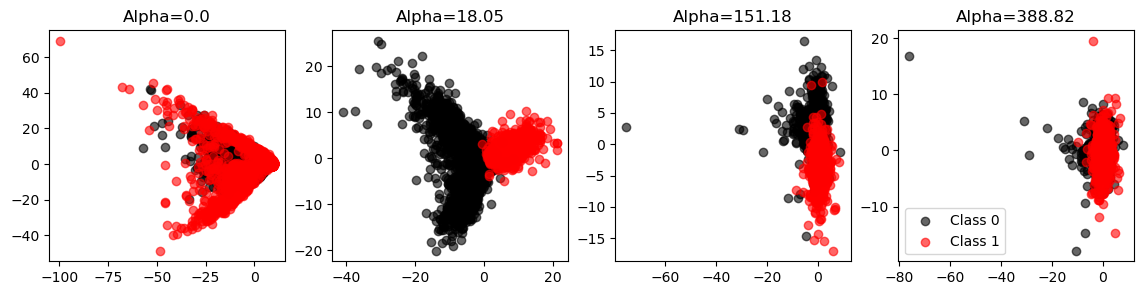

In [4]:
import numpy as np
from contrastive import CPCA

# 1. Log-transform
X_log = np.log1p(adata_X.X)
Y_log = np.log1p(adata_Y.X)

# 2. Contrastive PCA
mdl = CPCA(n_components=2)
labels = adata_X.obs['condition'].values
projected_data = mdl.fit_transform(X_log, Y_log, plot=True, active_labels=labels)



In [14]:
projected_data = mdl.fit_transform(X_log, Y_log, plot=False, active_labels=labels)

/opt/anaconda3/lib/python3.13/site-packages/contrastive/__init__.py:40: RuntimeWarning: invalid value encountered in divide
  standardized_array =  (array-np.mean(array,axis=0)) / np.std(array,axis=0)


In [ ]:
projected_data[1].shape

(7898, 2)

In [18]:
import numpy as np
from scipy.stats import ttest_ind

# Prepare data
H_transposed = projected_data[1]  # Shape: (7898, 2)
n_components = H_transposed.shape[1]
conditions = labels  # Your labels array

# Binary encoding: 0 for pre, 1 for post
condition_binary = np.array([0 if 'pre' in c.lower() else 1 for c in conditions])

print(f"Testing {n_components} components")
print(f"Pre-transplant: {sum(condition_binary==0)} samples")
print(f"Post-transplant: {sum(condition_binary==1)} samples")
print("\n" + "="*50)
print("Component | P-value      | Direction (Higher in)")
print("-"*50)

# Test both components
for i in range(n_components):
    factor_values = H_transposed[:, i]
    pre_vals = factor_values[condition_binary == 0]
    post_vals = factor_values[condition_binary == 1]
    
    # T-test
    t_stat, p_value = ttest_ind(pre_vals, post_vals, equal_var=False)
    
    # Prevent exact 0 p-value
    p_value = max(p_value, 1e-308)  # Smallest float value
    
    # Determine direction
    mean_pre = np.mean(pre_vals)
    mean_post = np.mean(post_vals)
    direction = "Post" if mean_post > mean_pre else "Pre"
    
    # Calculate effect size
    pooled_std = np.sqrt((np.std(pre_vals)**2 + np.std(post_vals)**2) / 2)
    cohens_d = (mean_post - mean_pre) / pooled_std
    
    print(f"Component {i+1:2} | {p_value:.4e} | {direction}-transplant (d={cohens_d:.3f})")

Testing 2 components
Pre-transplant: 3933 samples
Post-transplant: 3965 samples

Component | P-value      | Direction (Higher in)
--------------------------------------------------
Component  1 | 1.0000e-308 | Pre-transplant (d=-0.926)
Component  2 | 1.0000e-308 | Post-transplant (d=1.097)


In [490]:
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

fg= projected_data[2]
# Get ground truth labels
true_labels = adata_X.obs['condition'].values

# K-means clustering on NMF factors (2 clusters for 2 conditions)
kmeans = KMeans(n_clusters=2, random_state=42)
predicted_clusters = kmeans.fit_predict(fg)

# Calculate ARI
ari = adjusted_rand_score(true_labels, predicted_clusters)
print(f"ARI: {ari:.3f}")

ARI: 0.603


In [ ]:
PCA: 0.395
NMF: 0.336
cPCA: 0.603
bcNMF: 0.591

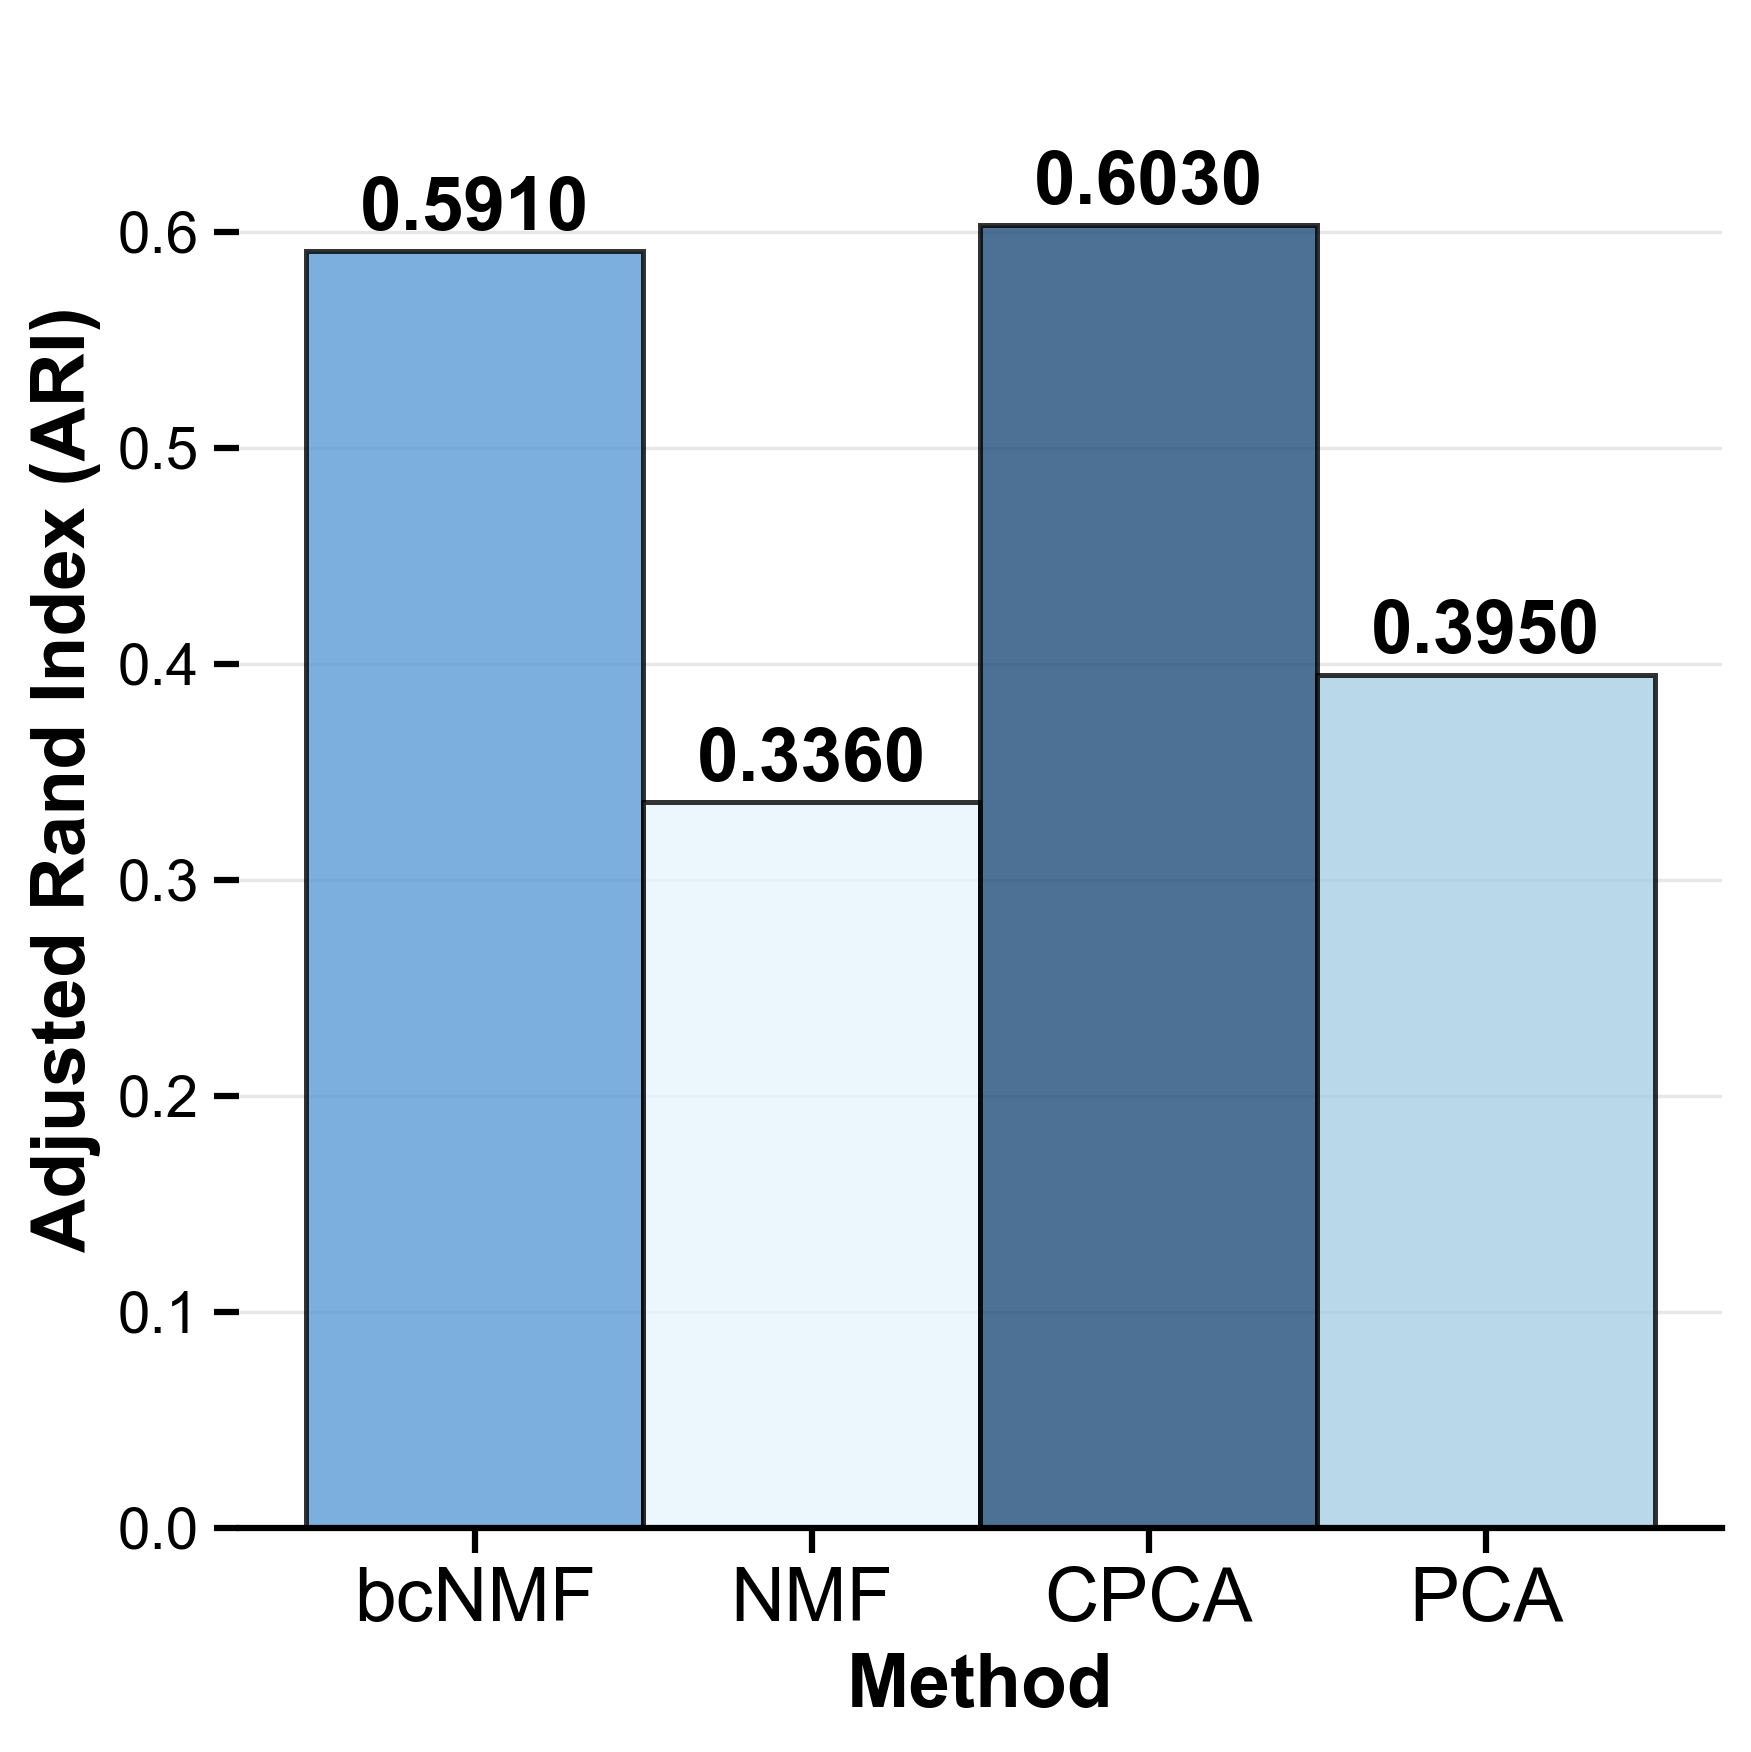

In [562]:
import matplotlib.pyplot as plt
import numpy as np

# Set style parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'Arial',
    'axes.linewidth': 1.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.5,
    'ytick.major.size': 6,
    'ytick.major.width': 1.5,
    'figure.dpi': 300
})

# Data - sorted by ARI score for color assignment
methods = ['bcNMF', 'NMF', 'CPCA', 'PCA']
ari_scores = [0.591, 0.336, 0.603, 0.395]

# Blue-green color palette from lightest to darkest
color_map = {
    0.336: '#E8F4FD',  # Lightest mint green (PCA - smallest value)
    0.395: '#A8D0E6',   # Light teal (NMF)
    0.591: '#5B9BD5',  # Medium teal (CPCA)
    0.603: '#1F4E79'    # Dark forest green (bcNMF - largest value)
}

colors = [color_map[score] for score in ari_scores]

# Create narrow figure - adjusted for vertical bars
fig, ax = plt.subplots(figsize=(6, 6))

# Vertical bar plot with no gaps
bars = ax.bar(methods, ari_scores, 
              color=colors, 
              alpha=0.8, 
              edgecolor='black', 
              linewidth=1.2,
              width=1.0)  # Full width, no gaps

# Add value labels on top of bars
for i, (bar, score) in enumerate(zip(bars, ari_scores)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.003,
            f'{score:.4f}',
            ha='center', va='bottom', 
            fontweight='bold', 
            fontsize=18)

# Customize
ax.set_ylabel('Adjusted Rand Index (ARI)', fontsize=18, fontweight='bold')
ax.set_xlabel('Method', fontsize=18, fontweight='bold')
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=14)

# Set limits
ax.set_ylim(0, max(ari_scores) * 1.15)

# Add grid
ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

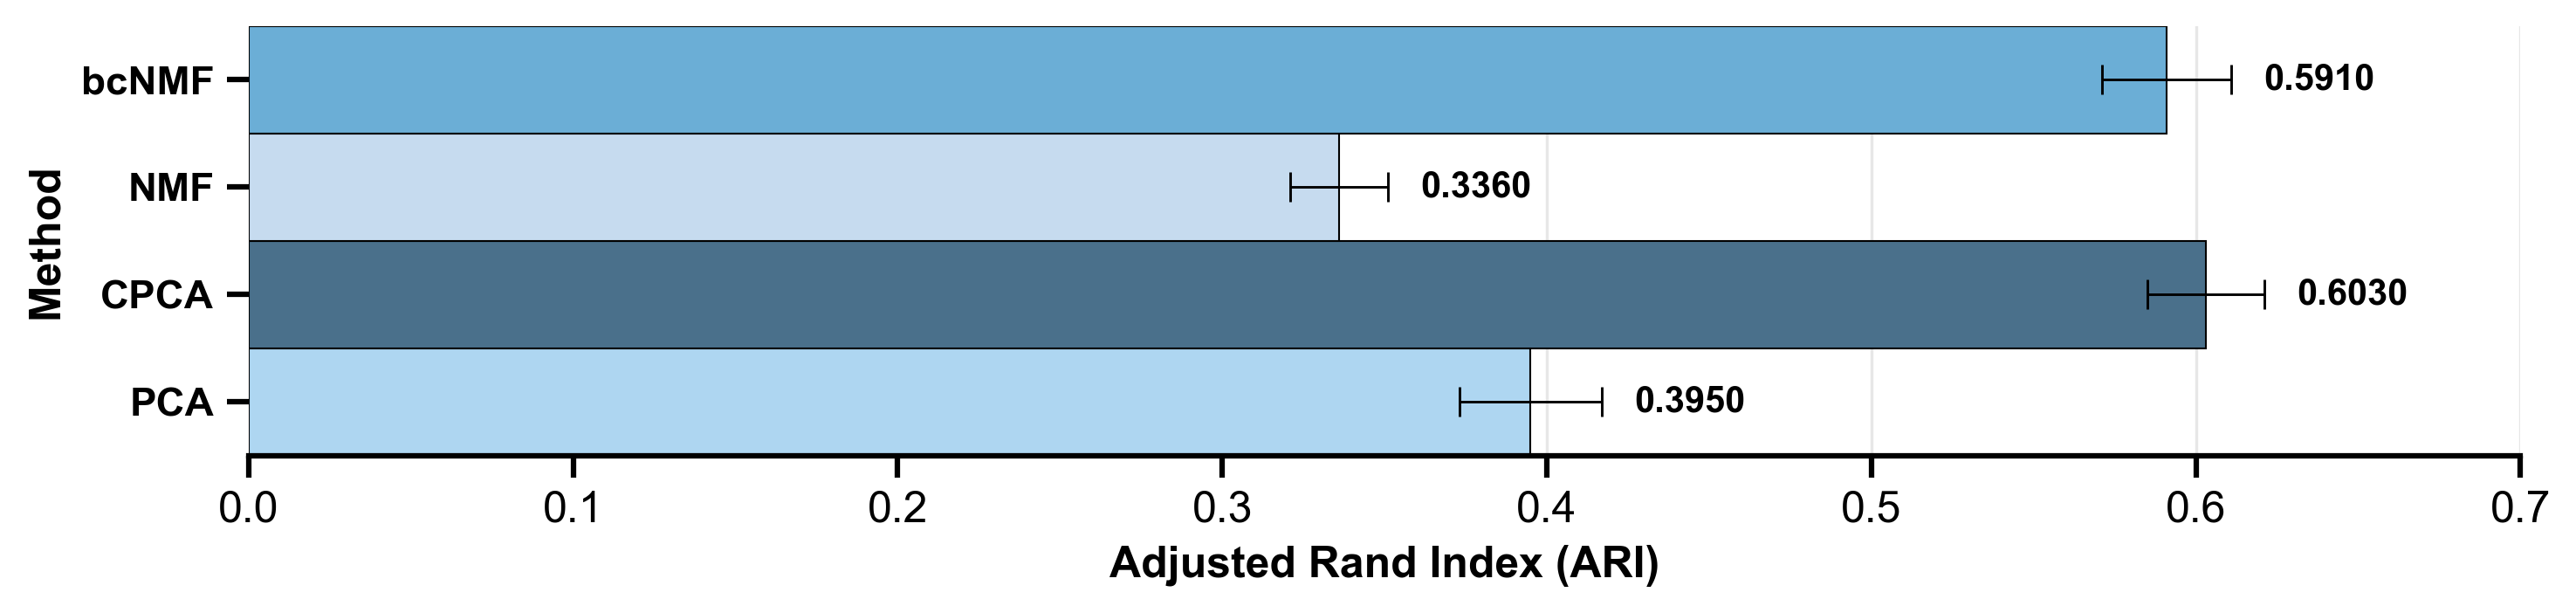

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Data
methods = ['PCA', 'CPCA', 'NMF', 'bcNMF']
ARI = [0.3950, 0.6030, 0.3360, 0.5910]

colors = ['#AED6F1', '#4A708B', '#C6DBEF', '#6BAED6']

# Create figure
fig, ax = plt.subplots(figsize=(10, 2.5))  # Reduced height for thinner look

# Define bar positions - THINNER bars with no gaps
bar_height = 0.08  # Much thinner bars (was 0.15)
n_bars = len(methods)

# Calculate positions so bars touch each other
y_positions = []
y_bottoms = []
for i in range(n_bars):
    bottom = i * bar_height
    y_bottoms.append(bottom)
    y_positions.append(bottom + bar_height/2)  # Center of bar

# Draw rectangles (bars)
for i, (method, value, color) in enumerate(zip(methods, ARI, colors)):
    rect = mpatches.Rectangle((0, y_bottoms[i]), value, bar_height,
                              facecolor=color, edgecolor='black', linewidth=0.5)
    ax.add_patch(rect)

# Add error bars - BIGGER
for i, (value, error) in enumerate(zip(ARI, SE)):
    ax.errorbar(value, y_positions[i], xerr=error, fmt='none',
                ecolor='black', capsize=4, capthick=0.7, linewidth=0.7)  # Increased capsize and linewidth
    
    # Add text labels
    ax.text(value + error + 0.01, y_positions[i], f'{value:.4f}',
            va='center', fontweight='bold', fontsize=10)

# Set y-axis labels
ax.set_yticks(y_positions)
ax.set_yticklabels(methods, fontweight='bold', fontsize=11)

# Set axes properties
ax.set_xlim(0, 0.7)
ax.set_ylim(0, n_bars * bar_height)
ax.set_xlabel('Adjusted Rand Index (ARI)', fontweight='bold', fontsize=12)
ax.set_ylabel('Method', fontweight='bold', fontsize=12)

# Grid
ax.grid(True, axis='x', alpha=0.3)
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

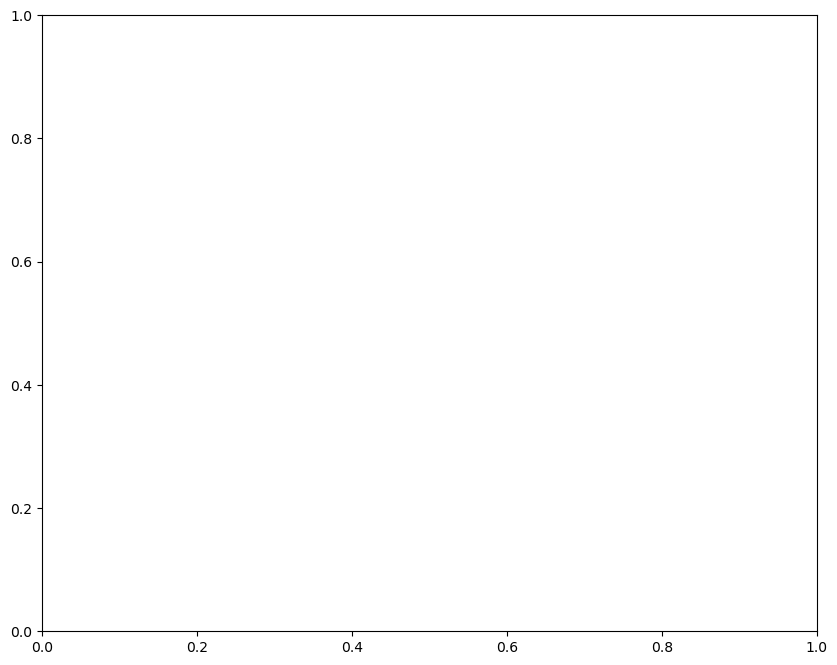

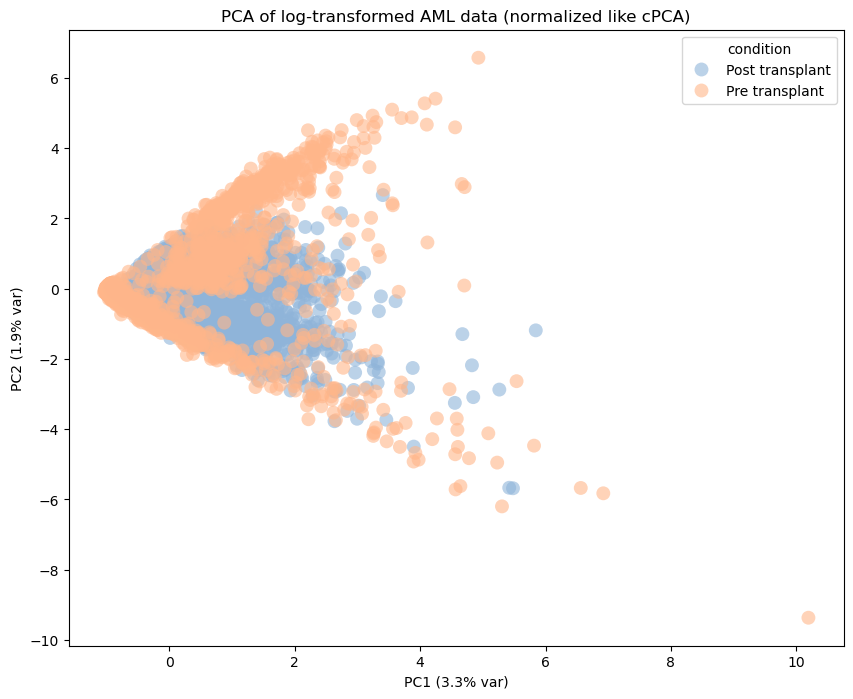

Variance explained: PC1=3.29%, PC2=1.88%
Component variance after scaling: [1. 1.]


In [9]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Log-transform
X_log = np.log1p(adata_X.X)

# 2. Standardize to match cPCA's normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# 3. PCA on scaled data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Scale components to unit variance (like cPCA does)
X_pca = X_pca / np.std(X_pca, axis=0)

# 5. Plot
color_palette = {
    'Post transplant': "#8FB4D9",  
    'Pre transplant': "#FFB68A",  
}

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=adata_X.obs['condition'],
    palette=color_palette,
    s=100,
    alpha=0.6,
    edgecolor='none'
)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('PCA of log-transformed AML data (normalized like cPCA)')

plt.show()

print(f"Variance explained: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")
print(f"Component variance after scaling: {np.var(X_pca, axis=0)}")

In [7]:
X = adata_X.X
K = 20
W_nmf_sse, H_nmf_sse, nmf_sse_perf = nmf_poisson(X.T, K, niter=100)

Iter: 0 .. Log likelihood: 4.3928
Iter: 1 .. Log likelihood: 4.4853
Iter: 2 .. Log likelihood: 4.5784
Iter: 3 .. Log likelihood: 4.6261
Iter: 4 .. Log likelihood: 4.6581
Iter: 5 .. Log likelihood: 4.6775
Iter: 6 .. Log likelihood: 4.6901
Iter: 7 .. Log likelihood: 4.6989
Iter: 8 .. Log likelihood: 4.7050
Iter: 9 .. Log likelihood: 4.7094
Iter: 10 .. Log likelihood: 4.7129
Iter: 11 .. Log likelihood: 4.7158
Iter: 12 .. Log likelihood: 4.7185
Iter: 13 .. Log likelihood: 4.7207
Iter: 14 .. Log likelihood: 4.7224
Iter: 15 .. Log likelihood: 4.7236
Iter: 16 .. Log likelihood: 4.7246
Iter: 17 .. Log likelihood: 4.7253
Iter: 18 .. Log likelihood: 4.7259
Iter: 19 .. Log likelihood: 4.7264
Iter: 20 .. Log likelihood: 4.7268
Iter: 21 .. Log likelihood: 4.7272
Iter: 22 .. Log likelihood: 4.7275
Iter: 23 .. Log likelihood: 4.7278
Iter: 24 .. Log likelihood: 4.7281
Iter: 25 .. Log likelihood: 4.7284
Iter: 26 .. Log likelihood: 4.7287
Iter: 27 .. Log likelihood: 4.7289
Iter: 28 .. Log likelihood: 4.

Number of NMF factors: 20


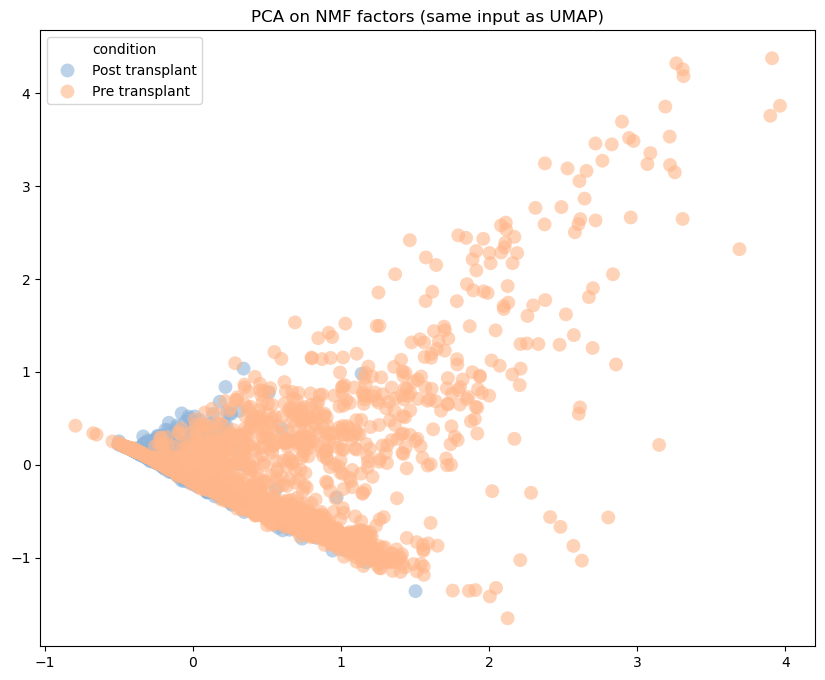

In [10]:
# Check how many NMF components you used
print(f"Number of NMF factors: {H_nmf_sse.shape[0]}")

# Try PCA on NMF factors (same feature space as UMAP)
from sklearn.decomposition import PCA

H_for_pca = H_nmf_sse.T  # Transpose so samples are rows
pca_nmf = PCA(n_components=2)
H_pca = pca_nmf.fit_transform(H_for_pca)

# Plot PCA on NMF factors
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(
    x=H_pca[:, 0],
    y=H_pca[:, 1],
    hue=adata_X.obs['condition'],
    palette=color_palette,
    s=100,
    alpha=0.6,
    edgecolor='none'
)
ax.set_title('PCA on NMF factors (same input as UMAP)')
plt.show()

Sparsity of NMF factors: 12.28%
Mean active factors per cell: 7.7
Median active factors per cell: 8.0


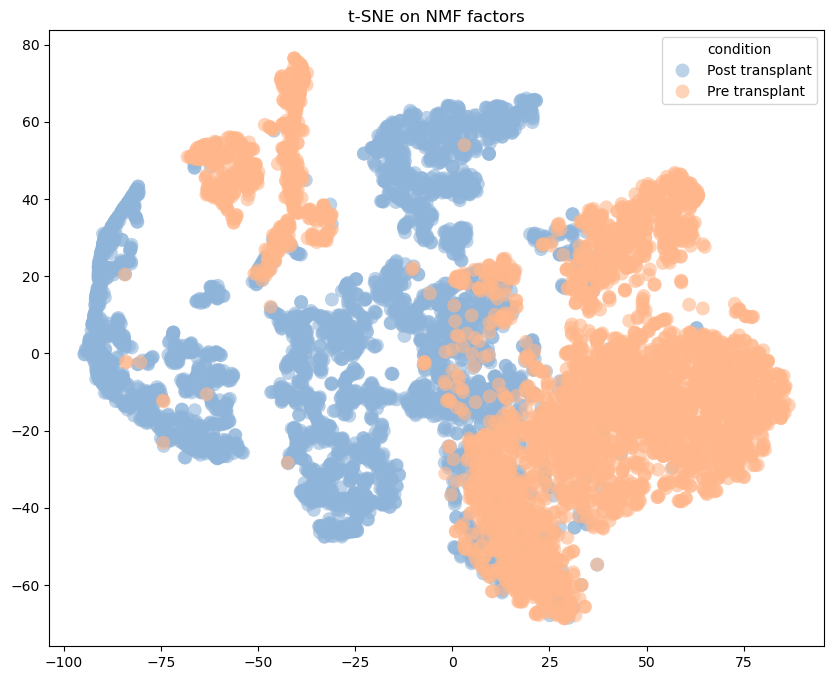

In [11]:
# Check sparsity of NMF factors
H_transposed = H_nmf_sse.T
sparsity = np.mean(H_transposed == 0)
print(f"Sparsity of NMF factors: {sparsity:.2%}")

# Check how many factors are active per cell
active_factors = np.sum(H_transposed > 0.01, axis=1)  # Factors with value > 0.01
print(f"Mean active factors per cell: {np.mean(active_factors):.1f}")
print(f"Median active factors per cell: {np.median(active_factors):.1f}")

# Try t-SNE as another non-linear method
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
H_tsne = tsne.fit_transform(H_transposed)

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(
    x=H_tsne[:, 0],
    y=H_tsne[:, 1],
    hue=adata_X.obs['condition'],
    palette=color_palette,
    s=100,
    alpha=0.6,
    edgecolor='none'
)
ax.set_title('t-SNE on NMF factors')
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


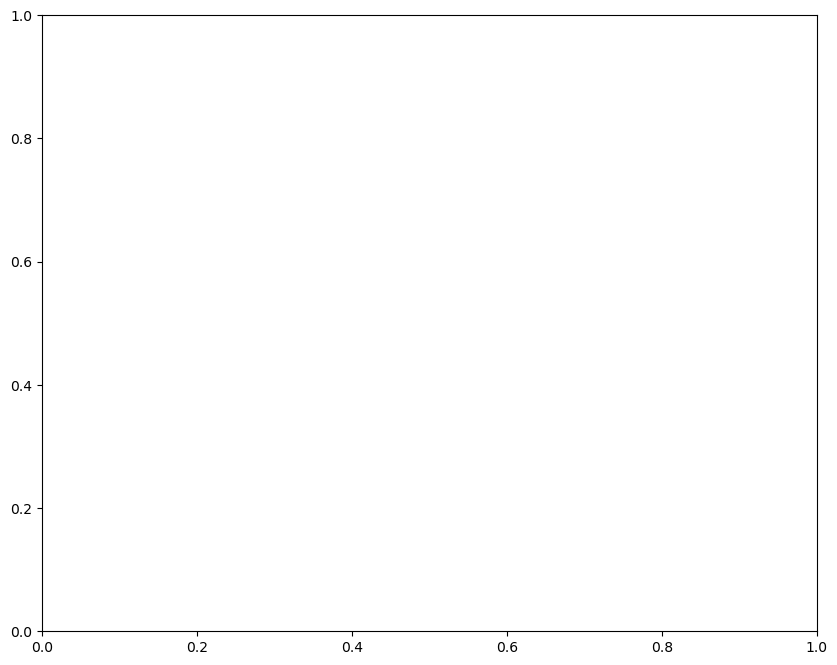

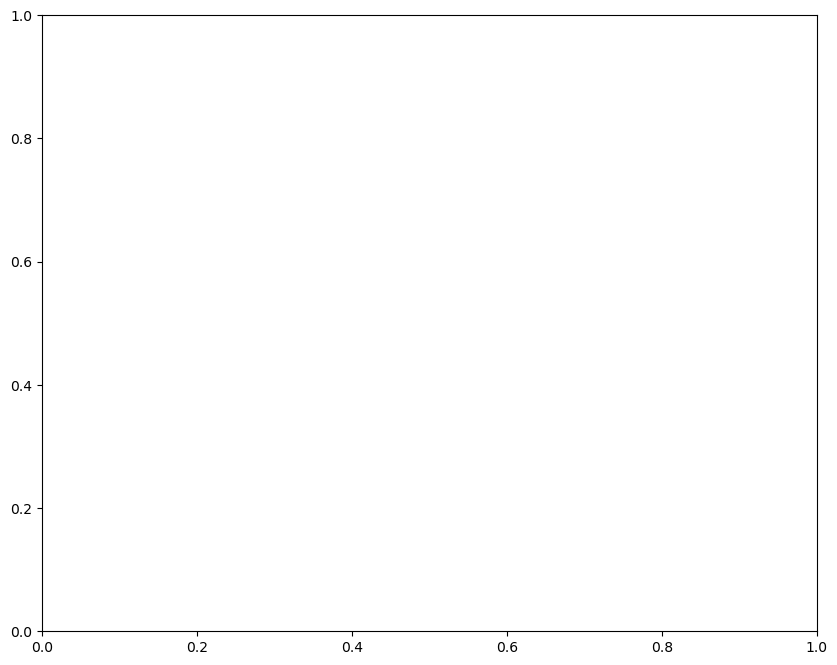

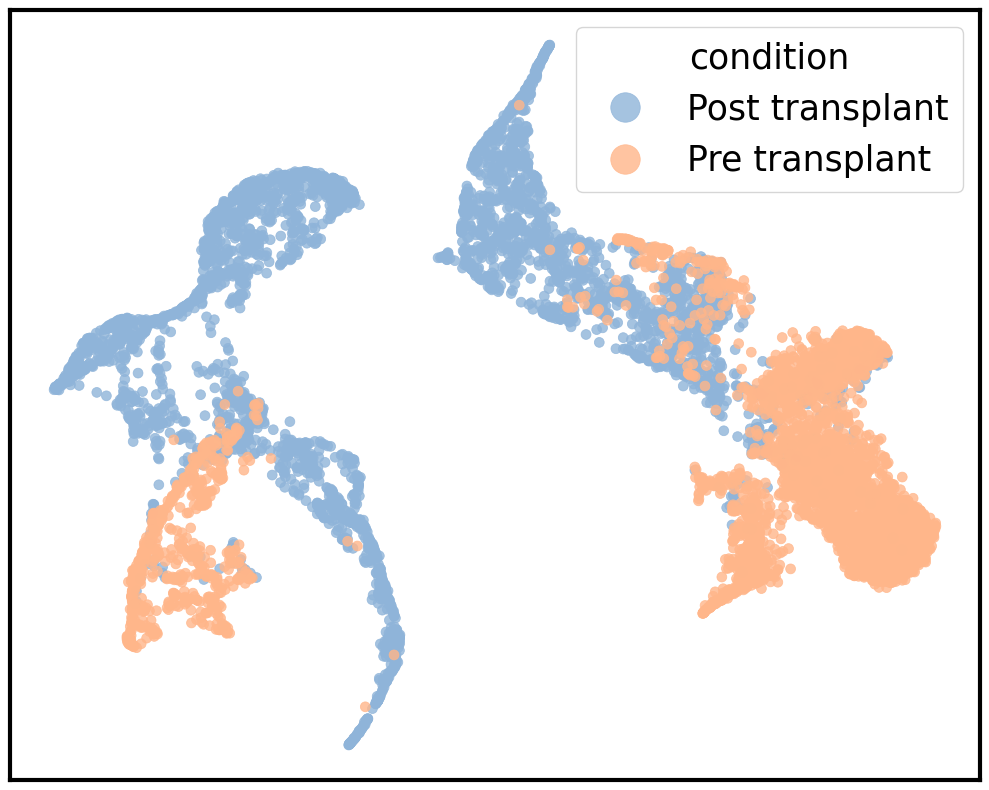

In [18]:
umap_reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,        # Higher min_dist for more separation
    n_components=2,
    random_state=42
)
H_umap = umap_reducer.fit_transform(H_nmf_sse.T)  # Transpose H so that rows correspond to samples

# Extract corresponding metadata from the adata_X1 subset
obs_subset = adata_X.obs.copy()

color_palette = {
   'Post transplant': "#8FB4D9",  
   'Pre transplant': "#FFB68A",  
   'Healthy': '#95E77E'                # Light green
}


fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(
    x=H_umap[:, 0],
    y=H_umap[:, 1],
    hue=obs_subset['condition'],  # Color by Broad categories
    palette=color_palette,         # Choose a color palette
    s=50,
    alpha=0.8,
    edgecolor=None
)

# Get and modify the legend (do this only once)
legend = ax.legend(title='condition', loc='best', fontsize=25, markerscale=3)
legend.get_title().set_fontsize(25)

# Remove ticks
plt.xticks([])
plt.yticks([])

# Set spine properties
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(3)

plt.tight_layout()
plt.show()

Using factors 1 and 0 with variances 2.2314 and 0.2762


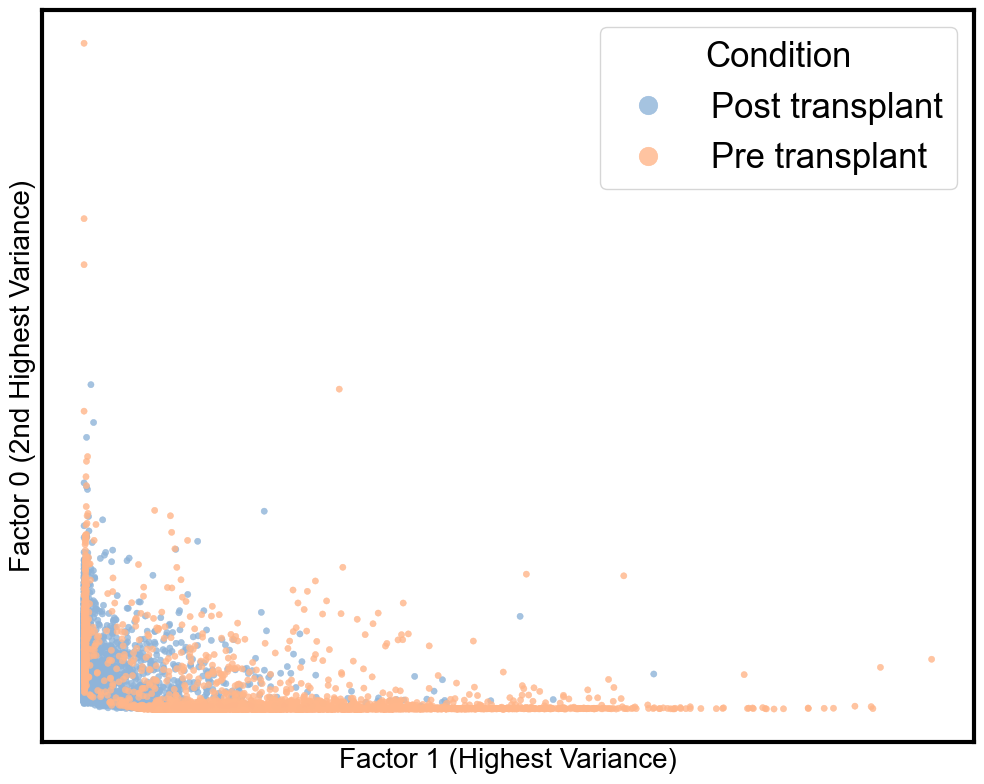

In [79]:
# Calculate variance for each factor (column) in H_nmf_sse
factor_variances = np.var(H_nmf_sse, axis=1)  # variance across samples for each factor

# Get indices of top 2 factors with highest variance
top_2_factors = np.argsort(factor_variances)[-2:][::-1]  # Get top 2 and reverse to get highest first

# Extract the top 2 factors
H_top2 = H_nmf_sse[top_2_factors, :].T  # Transpose so rows are samples

print(f"Using factors {top_2_factors[0]} and {top_2_factors[1]} with variances {factor_variances[top_2_factors[0]]:.4f} and {factor_variances[top_2_factors[1]]:.4f}")

# Extract corresponding metadata from the adata_X subset
obs_subset = adata_X.obs.copy()

# Fix color palette to match actual condition names
color_palette = {
   'Post transplant': "#8FB4D9",  
   'Pre transplant': "#FFB68A",  
   'Healthy': '#95E77E'
}

fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(
    x=H_top2[:, 0],  # First highest variance factor
    y=H_top2[:, 1],  # Second highest variance factor
    hue=obs_subset['condition'],
    palette=color_palette,
    s=20,
    alpha=0.8,
    edgecolor=None
)

# Get and modify the legend
legend = ax.legend(title='Condition', loc='best', fontsize=25, markerscale=3)
legend.get_title().set_fontsize(25)

# Add axis labels to show which factors
ax.set_xlabel(f'Factor {top_2_factors[0]} (Highest Variance)', fontsize=20)
ax.set_ylabel(f'Factor {top_2_factors[1]} (2nd Highest Variance)', fontsize=20)

# Remove ticks
plt.xticks([])
plt.yticks([])

# Set spine properties
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(3)

plt.tight_layout()
plt.show()

In [429]:
X = adata_X.X
Y = adata_Y.X
K = 20
alpha =0
W_nmf_sse, H_X_nmf_sse, H_Y_nmf_sse, nmf_sse_perf = contrastive_nmf_poisson(X.T, Y.T, K, alpha, niter=100)

Iter: 0 .. Contrastive Log Likelihood: 4.3897
Iter: 1 .. Contrastive Log Likelihood: 4.4558
Iter: 2 .. Contrastive Log Likelihood: 4.5441
Iter: 3 .. Contrastive Log Likelihood: 4.6015
Iter: 4 .. Contrastive Log Likelihood: 4.6419
Iter: 5 .. Contrastive Log Likelihood: 4.6697
Iter: 6 .. Contrastive Log Likelihood: 4.6867
Iter: 7 .. Contrastive Log Likelihood: 4.6973
Iter: 8 .. Contrastive Log Likelihood: 4.7050
Iter: 9 .. Contrastive Log Likelihood: 4.7106
Iter: 10 .. Contrastive Log Likelihood: 4.7147
Iter: 11 .. Contrastive Log Likelihood: 4.7178
Iter: 12 .. Contrastive Log Likelihood: 4.7203
Iter: 13 .. Contrastive Log Likelihood: 4.7224
Iter: 14 .. Contrastive Log Likelihood: 4.7242
Iter: 15 .. Contrastive Log Likelihood: 4.7257
Iter: 16 .. Contrastive Log Likelihood: 4.7269
Iter: 17 .. Contrastive Log Likelihood: 4.7279
Iter: 18 .. Contrastive Log Likelihood: 4.7287
Iter: 19 .. Contrastive Log Likelihood: 4.7293
Iter: 20 .. Contrastive Log Likelihood: 4.7299
Iter: 21 .. Contrastive

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


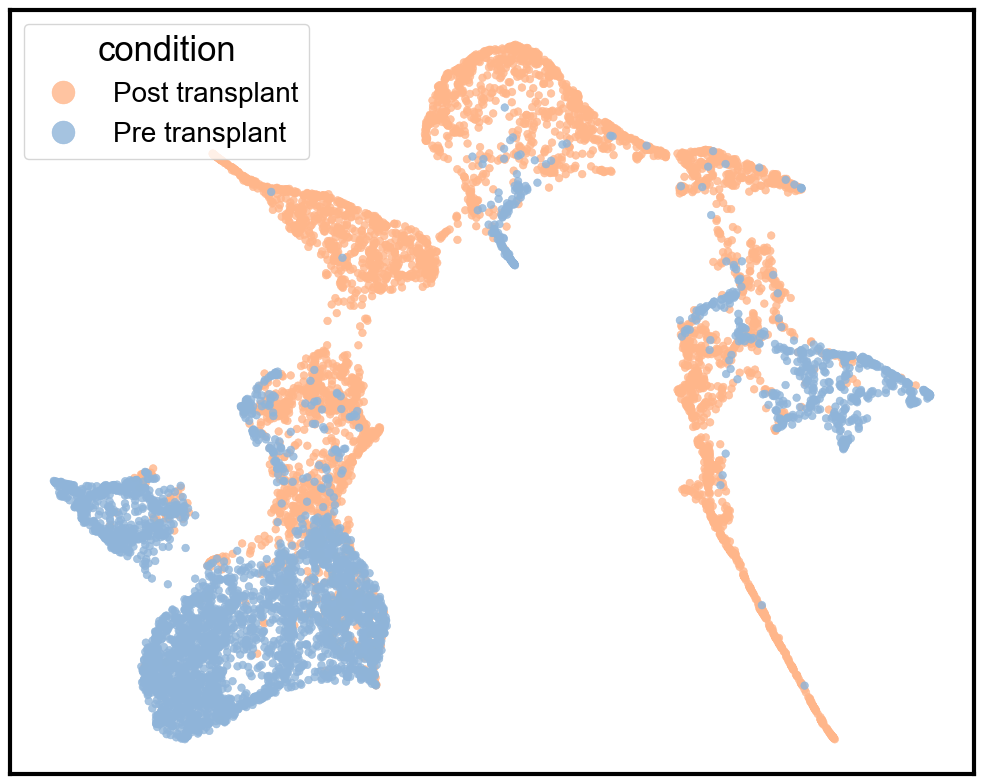

In [433]:
umap_reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,        # Higher min_dist for more separation
    n_components=2,         # Controls how spread out the embedding is
    random_state=42
)
H_umap = umap_reducer.fit_transform(H_X_nmf_sse.T)  # Transpose H so that rows correspond to samples

# Extract corresponding metadata from the adata_X1 subset
obs_subset = adata_X.obs.copy()

color_palette = {
   'Post transplant': "#FFB68A",  
   'Pre transplant': "#8FB4D9",  
   'Healthy': '#95E77E'                # Light green
}


fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(
    x=H_umap[:, 0],
    y=H_umap[:, 1],
    hue=obs_subset['condition'],  # Color by Broad categories
    palette=color_palette,         # Choose a color palette
    s=30,
    alpha=0.8,
    edgecolor=None
)

# Get and modify the legend (do this only once)
legend = ax.legend(title='condition', loc='best', fontsize=20, markerscale=3)
legend.get_title().set_fontsize(25)

# Remove ticks
plt.xticks([])
plt.yticks([])

# Set spine properties
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(3)

plt.tight_layout()
plt.show()

Sparsity of NMF factors: 37.83%
Mean active factors per cell: 0.5
Median active factors per cell: 0.0


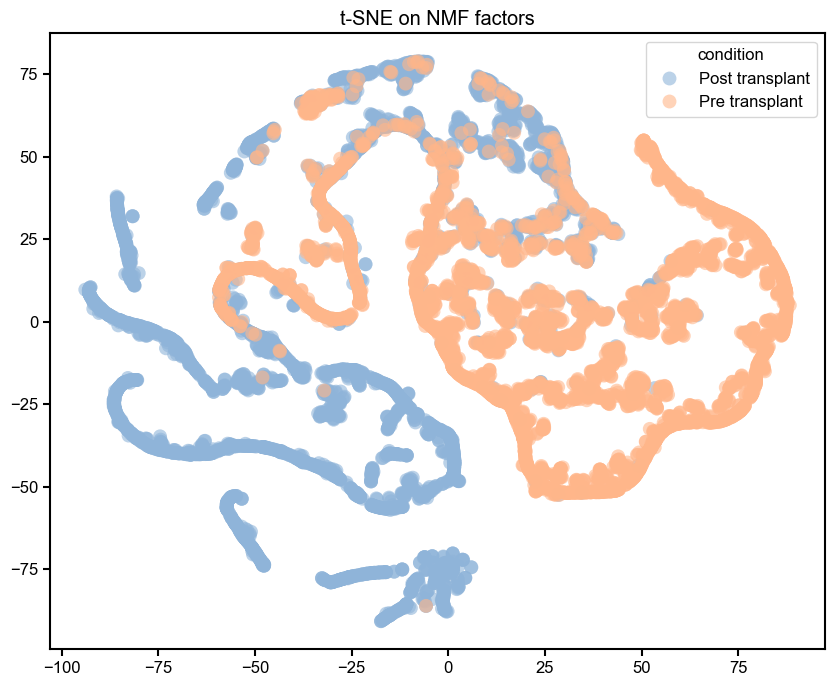

In [428]:
# Check sparsity of NMF factors
H_transposed = H_X_nmf_sse.T
sparsity = np.mean(H_transposed == 0)
print(f"Sparsity of NMF factors: {sparsity:.2%}")

# Check how many factors are active per cell
active_factors = np.sum(H_transposed > 0.01, axis=1)  # Factors with value > 0.01
print(f"Mean active factors per cell: {np.mean(active_factors):.1f}")
print(f"Median active factors per cell: {np.median(active_factors):.1f}")

# Try t-SNE as another non-linear method
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
H_tsne = tsne.fit_transform(H_transposed)

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(
    x=H_tsne[:, 0],
    y=H_tsne[:, 1],
    hue=adata_X.obs['condition'],
    palette=color_palette,
    s=100,
    alpha=0.6,
    edgecolor='none'
)
ax.set_title('t-SNE on NMF factors')
plt.show()

Using factors 1 and 0 with variances 0.1555 and 0.0000


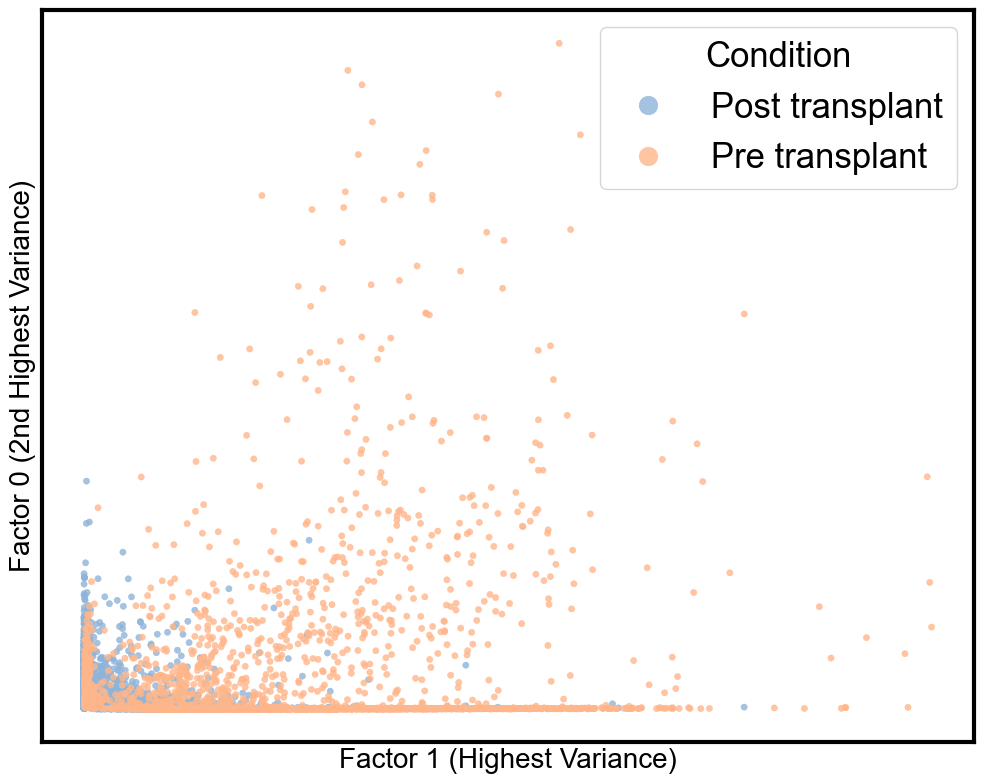

In [424]:
# Calculate variance for each factor (column) in H_nmf_sse
factor_variances = np.var(H_X_nmf_sse, axis=1)  # variance across samples for each factor

# Get indices of top 2 factors with highest variance
top_2_factors = np.argsort(factor_variances)[-2:][::-1]  # Get top 2 and reverse to get highest first

# Extract the top 2 factors
H_top2 = H_X_nmf_sse[top_2_factors, :].T  # Transpose so rows are samples

print(f"Using factors {top_2_factors[0]} and {top_2_factors[1]} with variances {factor_variances[top_2_factors[0]]:.4f} and {factor_variances[top_2_factors[1]]:.4f}")

# Extract corresponding metadata from the adata_X subset
obs_subset = adata_X.obs.copy()

# Fix color palette to match actual condition names
color_palette = {
   'Post transplant': "#8FB4D9",  
   'Pre transplant': "#FFB68A",  
   'Healthy': '#95E77E'
}

fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(
    x=H_top2[:, 0],  # First highest variance factor
    y=H_top2[:, 1],  # Second highest variance factor
    hue=obs_subset['condition'],
    palette=color_palette,
    s=20,
    alpha=0.8,
    edgecolor=None
)

# Get and modify the legend
legend = ax.legend(title='Condition', loc='best', fontsize=25, markerscale=3)
legend.get_title().set_fontsize(25)

# Add axis labels to show which factors
ax.set_xlabel(f'Factor {top_2_factors[0]} (Highest Variance)', fontsize=20)
ax.set_ylabel(f'Factor {top_2_factors[1]} (2nd Highest Variance)', fontsize=20)

# Remove ticks
plt.xticks([])
plt.yticks([])

# Set spine properties
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(3)

plt.tight_layout()
plt.show()

In [167]:
X = adata_X.X
Y = adata_Y.X

# 1. Log-transform
X_log = np.log1p(X)
Y_log = np.log1p(Y)

# 2. Standardize (optional but recommended for consistency with PCA/cPCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
Y_scaled = scaler.transform(Y_log)

In [419]:
X


array([[11.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]])

In [380]:
X_scaled = X_scaled / np.std(X_scaled, axis=0)

/var/folders/v5/x07md57n5fn41s9ln1bztt9w0000gn/T/ipykernel_27347/1428600204.py:1: RuntimeWarning: invalid value encountered in divide
  X_scaled = X_scaled / np.std(X_scaled, axis=0)


In [439]:
K = 100
W_nmf_sse, H_nmf_sse, nmf_sse_perf = nmf_sse(X_log.T, K, niter=100)

Iter: 0 .. MSE: 0.0586
Iter: 1 .. MSE: 0.0483
Iter: 2 .. MSE: 0.0443
Iter: 3 .. MSE: 0.0392
Iter: 4 .. MSE: 0.0360
Iter: 5 .. MSE: 0.0342
Iter: 6 .. MSE: 0.0326
Iter: 7 .. MSE: 0.0311
Iter: 8 .. MSE: 0.0297
Iter: 9 .. MSE: 0.0285
Iter: 10 .. MSE: 0.0275
Iter: 11 .. MSE: 0.0268
Iter: 12 .. MSE: 0.0262
Iter: 13 .. MSE: 0.0257
Iter: 14 .. MSE: 0.0253
Iter: 15 .. MSE: 0.0249
Iter: 16 .. MSE: 0.0246
Iter: 17 .. MSE: 0.0243
Iter: 18 .. MSE: 0.0241
Iter: 19 .. MSE: 0.0238
Iter: 20 .. MSE: 0.0236
Iter: 21 .. MSE: 0.0234
Iter: 22 .. MSE: 0.0232
Iter: 23 .. MSE: 0.0230
Iter: 24 .. MSE: 0.0229
Iter: 25 .. MSE: 0.0227
Iter: 26 .. MSE: 0.0225
Iter: 27 .. MSE: 0.0224
Iter: 28 .. MSE: 0.0222
Iter: 29 .. MSE: 0.0221
Iter: 30 .. MSE: 0.0220
Iter: 31 .. MSE: 0.0219
Iter: 32 .. MSE: 0.0218
Iter: 33 .. MSE: 0.0217
Iter: 34 .. MSE: 0.0216
Iter: 35 .. MSE: 0.0215
Iter: 36 .. MSE: 0.0214
Iter: 37 .. MSE: 0.0213
Iter: 38 .. MSE: 0.0212
Iter: 39 .. MSE: 0.0212
Iter: 40 .. MSE: 0.0211
Iter: 41 .. MSE: 0.0210
It

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


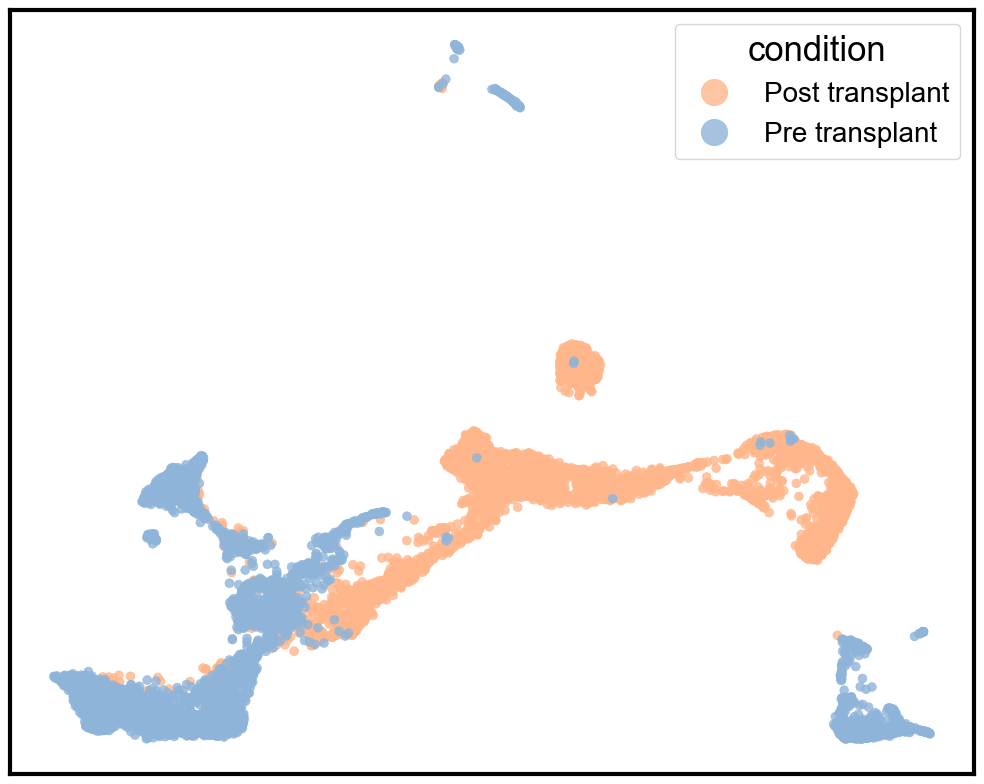

In [452]:
umap_reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,        # Higher min_dist for more separation
    n_components=2,
    random_state=42
)
H_umap = umap_reducer.fit_transform(H_nmf_sse.T)  # Transpose H so that rows correspond to samples

# Extract corresponding metadata from the adata_X1 subset
obs_subset = adata_X.obs.copy()

color_palette = {
   'Pre transplant': "#8FB4D9",  
   'Post transplant': "#FFB68A"
}


fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(
    x=H_umap[:, 0],
    y=H_umap[:, 1],
    hue=obs_subset['condition'],  # Color by Broad categories
    palette=color_palette,         # Choose a color palette
    s=40,
    alpha=0.8,
    edgecolor=None
)

# Get and modify the legend (do this only once)
legend = ax.legend(title='condition', loc='best', fontsize=20, markerscale=3)
legend.get_title().set_fontsize(25)

# Remove ticks
plt.xticks([])
plt.yticks([])

# Set spine properties
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(3)

plt.tight_layout()
plt.show()

In [8]:
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

In [453]:
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

# Get ground truth labels
true_labels = adata_X.obs['condition'].values

# K-means clustering on NMF factors (2 clusters for 2 conditions)
kmeans = KMeans(n_clusters=2, random_state=42)
predicted_clusters = kmeans.fit_predict(H_umap)

# Calculate ARI
ari = adjusted_rand_score(true_labels, predicted_clusters)
print(f"ARI: {ari:.3f}")

ARI: 0.367


In [237]:
# Check if increasing clusters improves anything
for k in [3, 4, 5, 6]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(H_umap)  # Use UMAP coordinates
    ari = adjusted_rand_score(true_labels, clusters)
    print(f"k={k}: ARI={ari:.3f}")

# See distribution of conditions across visual clusters
kmeans_5 = KMeans(n_clusters=5, random_state=42)
clusters_5 = kmeans_5.fit_predict(H_umap)
for i in range(5):
    mask = clusters_5 == i
    conditions_in_cluster = true_labels[mask]
    pre_count = np.sum(conditions_in_cluster == 'AML_transplant_pre')
    post_count = np.sum(conditions_in_cluster == 'AML_transplant_post')
    print(f"Cluster {i}: Pre={pre_count}, Post={post_count}")

k=3: ARI=0.318
k=4: ARI=0.328
k=5: ARI=0.275
k=6: ARI=0.343
Cluster 0: Pre=0, Post=0
Cluster 1: Pre=0, Post=0
Cluster 2: Pre=0, Post=0
Cluster 3: Pre=0, Post=0
Cluster 4: Pre=0, Post=0


In [557]:
K = 10
alpha = 0
W_nmf_sse, H_X_nmf_sse, H_Y_nmf_sse, nmf_sse_perf = contrastive_nmf_sse(X_log.T, Y_log.T, K, alpha, niter=10)

Iter: 0 .. MSE: 0.0593
Iter: 1 .. MSE: 0.0497
Iter: 2 .. MSE: 0.0467
Iter: 3 .. MSE: 0.0428
Iter: 4 .. MSE: 0.0382
Iter: 5 .. MSE: 0.0357
Iter: 6 .. MSE: 0.0344
Iter: 7 .. MSE: 0.0335
Iter: 8 .. MSE: 0.0328
Iter: 9 .. MSE: 0.0321


In [416]:
import numpy as np

# Your H_X_nmf_sse is currently (10, 7898), need to transpose to get (7898, 10)
H_transposed = H_X_nmf_sse.T  # Now shape is (7898, 10)

# Ensure all values are non-negative (they should already be from NMF, but just in case)
H_positive = np.maximum(H_transposed, 0)

# Normalize each row to sum to 1
row_sums = H_positive.sum(axis=1, keepdims=True)
# Avoid division by zero
row_sums[row_sums == 0] = 1
H_normalized = H_positive / row_sums

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


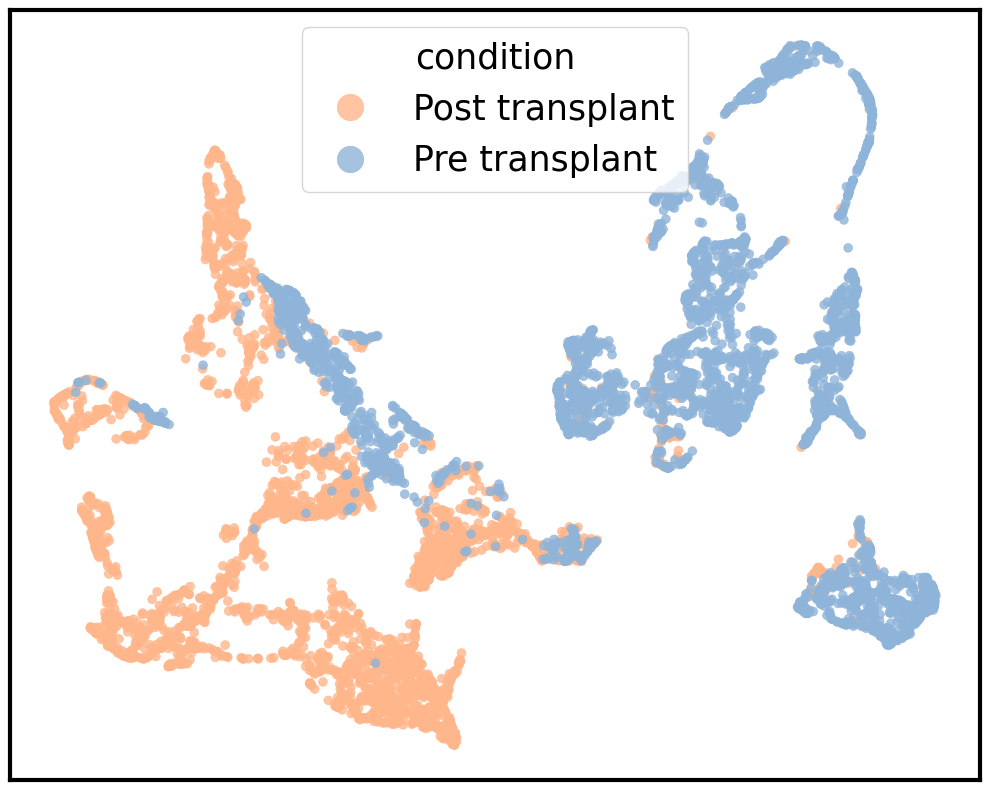

In [14]:
umap_reducer = umap.UMAP(   # Higher min_dist for more separation
    n_components=2,
    random_state=42
)
H_umap = umap_reducer.fit_transform(H_X_nmf_sse.T)  # Transpose H so that rows correspond to samples

# Extract corresponding metadata from the adata_X1 subset
obs_subset = adata_X.obs.copy()

color_palette = {
    'Post transplant': "#FFB68A",
   'Pre transplant': "#8FB4D9"
}


fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(
    x=H_umap[:, 0],
    y=H_umap[:, 1],
    hue=obs_subset['condition'],  # Color by Broad categories
    palette=color_palette,         # Choose a color palette
    s=40,
    alpha=0.8,
    edgecolor=None
)

# Get and modify the legend (do this only once)
legend = ax.legend(title='condition', loc='best', fontsize=25, markerscale=3)
legend.get_title().set_fontsize(25)

# Remove ticks
plt.xticks([])
plt.yticks([])

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(3)
    spine.set_visible(True)  # Make sure all spines are visible

# Alternatively, if you want to ensure all four sides have the border:
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_edgecolor('black')
    ax.spines[spine].set_linewidth(3)

plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import umap
import matplotlib.pyplot as plt

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP coords shape: (7898, 2)
UMAP coords range: [-10.35, 19.85]


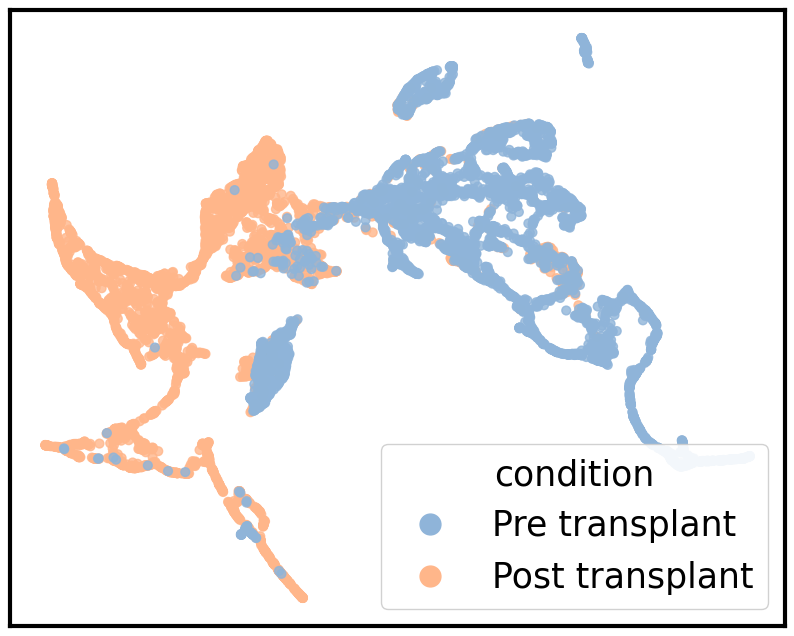

In [11]:
import numpy as np
import umap
import matplotlib.pyplot as plt

# Normalize H_X_nmf_sse
H_normalized = H_X_nmf_sse / H_X_nmf_sse.sum(axis=0, keepdims=True)
H_normalized_T = H_normalized.T

# Compute UMAP
reducer = umap.UMAP(random_state=42)
umap_coords = reducer.fit_transform(H_normalized_T)

# Check that we have data
print(f"UMAP coords shape: {umap_coords.shape}")
print(f"UMAP coords range: [{umap_coords.min():.2f}, {umap_coords.max():.2f}]")

# Get labels
true_labels = adata_X.obs['condition'].values

# Create color list based on labels
colors = []
for label in true_labels:
    if 'post' in label.lower():
        colors.append("#FFB68A")  # Post transplant
    else:
        colors.append("#8FB4D9")  # Pre transplant

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(umap_coords[:, 0], umap_coords[:, 1], c=colors, s=40, alpha=0.8)
#ax.set_xlabel('UMAP 1')
#ax.set_ylabel('UMAP 2')
#ax.set_title('UMAP of Normalized NMF Factors')

import matplotlib.lines as mlines

# Create circle markers for legend
pre_marker = mlines.Line2D([], [], color='#8FB4D9', marker='o', linestyle='None',
                          markersize=15, label='Pre transplant')
post_marker = mlines.Line2D([], [], color='#FFB68A', marker='o', linestyle='None', 
                           markersize=15, label='Post transplant')

legend = ax.legend(handles=[pre_marker, post_marker], 
                   title='condition', 
                   loc='best', 
                   fontsize=25,
                   frameon=True,
                   fancybox=True,
                   framealpha=0.9)
legend.get_title().set_fontsize(25)
plt.xticks([])
plt.yticks([])

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(3)
    spine.set_visible(True)  # Make sure all spines are visible

# Alternatively, if you want to ensure all four sides have the border:
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_edgecolor('black')
    ax.spines[spine].set_linewidth(3)

plt.show()

In [340]:
np.save('W_nmf_sse_leukemia.npy', W_nmf_sse)
np.save('H_X_nmf_sse_leukemia.npy', H_X_nmf_sse)
np.save('H_Y_nmf_sse_leukemia.npy', H_Y_nmf_sse)

In [5]:
W_nmf_sse = np.load('W_nmf_sse_leukemia.npy')
H_X_nmf_sse = np.load('H_X_nmf_sse_leukemia.npy')
H_Y_nmf_sse = np.load('H_Y_nmf_sse_leukemia.npy')

In [6]:
import numpy as np
from tqdm import tqdm
 
H_transposed = H_X_nmf_sse.T

def bootstrap_test(pre_vals, post_vals, n_bootstrap=10000):
    """Simple bootstrap permutation test"""
    # Observed difference
    obs_diff = np.mean(post_vals) - np.mean(pre_vals)
    
    # Combine all data
    combined = np.concatenate([pre_vals, post_vals])
    n_pre = len(pre_vals)
    
    # Bootstrap
    extreme_count = 0
    for _ in tqdm(range(n_bootstrap)):
        # Permute and split
        permuted = np.random.permutation(combined)
        perm_diff = np.mean(permuted[n_pre:]) - np.mean(permuted[:n_pre])
        
        # Count extreme cases
        if abs(perm_diff) >= abs(obs_diff):
            extreme_count += 1
    
    # Calculate p-value
    p_value = (extreme_count + 1) / (n_bootstrap + 1)
    
    return obs_diff, p_value, extreme_count

# Test components 8 and 10
components = [7, 9]  # 0-indexed
names = [8, 10]

print("="*50)
print("BOOTSTRAP PERMUTATION TEST RESULTS")
print("="*50)

for comp_idx, comp_name in zip(components, names):
    # Get data
    factor_values = H_transposed[:, comp_idx]
    pre_vals = factor_values[condition_binary == 0]
    post_vals = factor_values[condition_binary == 1]
    
    # Run test
    obs_diff, p_value, n_extreme = bootstrap_test(pre_vals, post_vals, n_bootstrap=10000)
    
    print(f"\nComponent {comp_name}:")
    print(f"  Observed difference: {obs_diff:.6f}")
    print(f"  Bootstrap p-value: {p_value:.6e}")
    print(f"  Extreme permutations: {n_extreme}/10000")
    
    if n_extreme == 0:
        print(f"  → True p < 1e-4 (no permutations as extreme)")

BOOTSTRAP PERMUTATION TEST RESULTS


NameError: name 'condition_binary' is not defined

In [15]:
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

# Get true labels
true_labels = adata_X.obs['condition'].values

# Cluster UMAP coordinates with k=2 (matching number of conditions)
kmeans = KMeans(n_clusters=2, random_state=42)
umap_clusters = kmeans.fit_predict(H_umap)

# Calculate ARI
ari = adjusted_rand_score(true_labels, umap_clusters)
print(f"ARI for UMAP clustering: {ari:.3f}")

ARI for UMAP clustering: 0.551


In [ ]:
K = 10
alpha = 20 
ari = .550

In [13]:
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

# Get ground truth labels
true_labels = adata_X.obs['condition'].values

# K-means clustering on NMF factors (2 clusters for 2 conditions)
kmeans = KMeans(n_clusters=2, random_state=42)
predicted_clusters = kmeans.fit_predict(H_X_nmf_sse.T)

# Calculate ARI
ari = adjusted_rand_score(true_labels, predicted_clusters)
print(f"ARI: {ari:.3f}")

ARI: 0.005


<Figure size 1200x600 with 0 Axes>

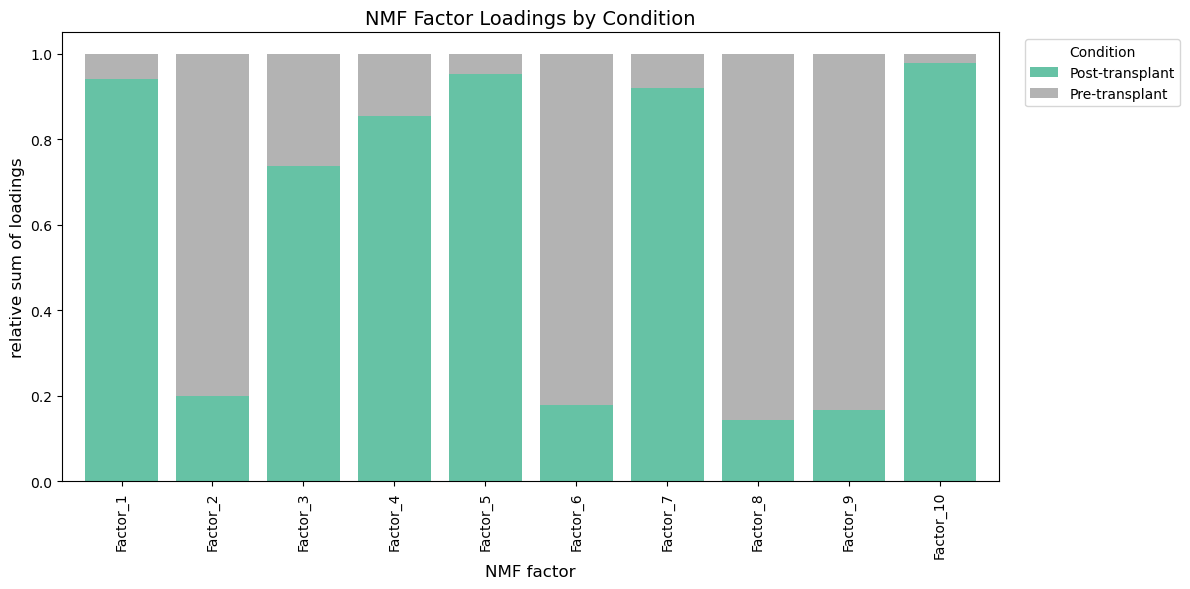

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Get the transposed H matrix (cells x factors)
H_transposed = H_X_nmf_sse.T

# 2) Create a DataFrame for factor loadings
#    Each row: a cell. Each column: a factor
K = H_transposed.shape[1]
factors_df = pd.DataFrame(
    H_transposed, 
    columns=[f'Factor_{i+1}' for i in range(K)]
)

# 3) Add condition information (Pre vs Post transplant)
#    Create condition labels matching your label convention
n_rows_post = matrix_27_post.shape[1]  # Number of cells in post-transplant
n_rows_pre = matrix_27_pre.shape[1]    # Number of cells in pre-transplant

condition_labels = ['Post-transplant'] * n_rows_post + ['Pre-transplant'] * n_rows_pre
factors_df['Condition'] = condition_labels

# 4) Sum factor loadings by condition
grouped_loadings = factors_df.groupby('Condition').sum()  # shape: (2, K)

# 5) Convert absolute loadings to relative fractions
relative_loadings = grouped_loadings.div(grouped_loadings.sum(axis=0), axis=1)

# 6) Plot the stacked bar chart
plt.figure(figsize=(12, 6))

# Transpose so that each bar = factor, and stacked colors = conditions
relative_loadings.T.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    width=0.8,
    colormap='Set2',        # Choose a color palette
    edgecolor='none'
)

plt.ylabel('relative sum of loadings', fontsize=12)
plt.xlabel('NMF factor', fontsize=12)
plt.title('NMF Factor Loadings by Condition', fontsize=14)

# Put legend outside for clarity
plt.legend(
    title='Condition',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=10
)

plt.tight_layout()
plt.show()

In [19]:
hvg_genes['gene_name'].values

NameError: name 'hvg_genes' is not defined

In [20]:
import numpy as np
from scipy.stats import ttest_ind

# Prepare data
H_transposed = H_X_nmf_sse.T  # Shape: (n_samples, n_components)
n_components = H_transposed.shape[1]
conditions = adata_X.obs['condition'].values

# Binary encoding: 0 for pre, 1 for post
condition_binary = np.array([0 if 'pre' in c.lower() else 1 for c in conditions])

print(f"Testing {n_components} components")
print(f"Pre-transplant: {sum(condition_binary==0)} samples")
print(f"Post-transplant: {sum(condition_binary==1)} samples")
print("\n" + "="*60)
print("Component | P-value      | Direction (Higher in)")
print("-"*60)

# Test all components
results = []
for i in range(n_components):
    factor_values = H_transposed[:, i]
    pre_vals = factor_values[condition_binary == 0]
    post_vals = factor_values[condition_binary == 1]
    
    # T-test
    t_stat, p_value = ttest_ind(pre_vals, post_vals, equal_var=False)
    
    # Prevent exact 0 p-value
    p_value = max(p_value, 1e-308)  # Smallest float value
    
    # Determine direction
    mean_pre = np.mean(pre_vals)
    mean_post = np.mean(post_vals)
    direction = "Post" if mean_post > mean_pre else "Pre"
    
    results.append({
        'component': i,
        'p_value': p_value,
        'direction': direction,
        'mean_diff': mean_post - mean_pre
    })
    
    print(f"Component {i+1:2} | {p_value:.4e} | {direction}-transplant")

# Sort by p-value and get top 4
results_sorted = sorted(results, key=lambda x: x['p_value'])
top4 = results_sorted[:4]

print("\n" + "="*60)
print("TOP 4 MOST SIGNIFICANT COMPONENTS:")
print("-"*60)
for r in top4:
    print(f"Component {r['component']+1}: p={r['p_value']:.4e}, Higher in {r['direction']}")

# Store indices for later use
top4_idx = [r['component'] for r in top4]

Testing 10 components
Pre-transplant: 3933 samples
Post-transplant: 3965 samples

Component | P-value      | Direction (Higher in)
------------------------------------------------------------
Component  1 | 5.2495e-294 | Post-transplant
Component  2 | 1.9362e-271 | Pre-transplant
Component  3 | 2.8246e-52 | Post-transplant
Component  4 | 2.8285e-64 | Post-transplant
Component  5 | 4.4968e-163 | Post-transplant
Component  6 | 3.7557e-304 | Pre-transplant
Component  7 | 7.4470e-134 | Post-transplant
Component  8 | 1.0000e-308 | Pre-transplant
Component  9 | 4.6517e-155 | Pre-transplant
Component 10 | 1.0000e-308 | Post-transplant

TOP 4 MOST SIGNIFICANT COMPONENTS:
------------------------------------------------------------
Component 8: p=1.0000e-308, Higher in Pre
Component 10: p=1.0000e-308, Higher in Post
Component 6: p=3.7557e-304, Higher in Pre
Component 1: p=5.2495e-294, Higher in Post


/var/folders/v5/x07md57n5fn41s9ln1bztt9w0000gn/T/ipykernel_65711/1450991066.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=['Pre', 'Post'], patch_artist=True,
/opt/anaconda3/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 22.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/var/folders/v5/x07md57n5fn41s9ln1bztt9w0000gn/T/ipykernel_65711/1450991066.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=['Pre', 'Post'], patch_artist=True,
/opt/anaconda3/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 31.2% of the points cannot be placed; you

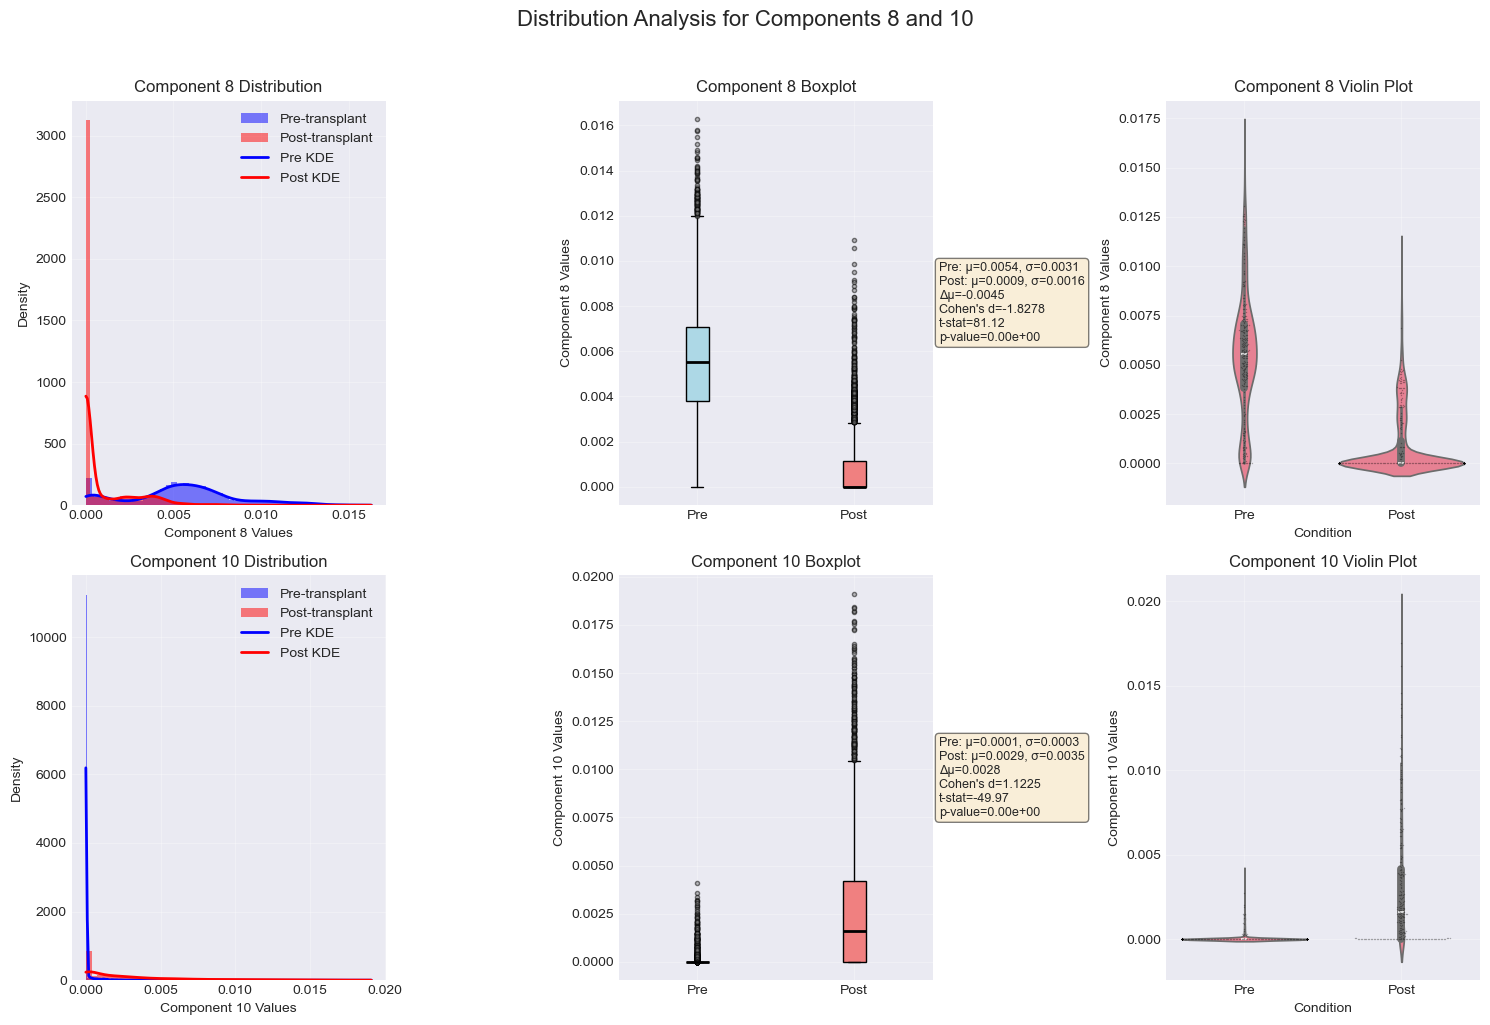

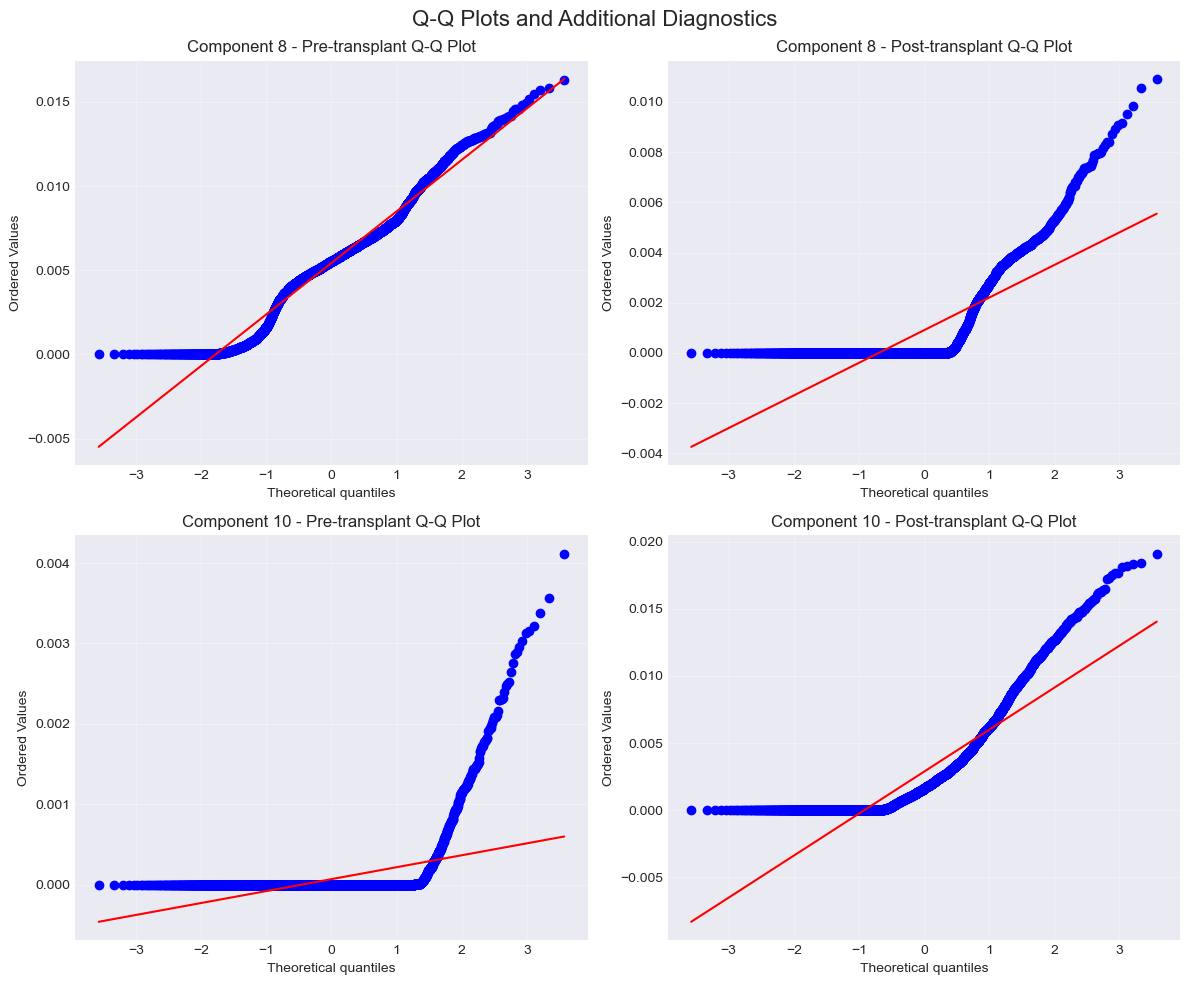


DETAILED STATISTICAL ANALYSIS

Component 8:
----------------------------------------
Pre-transplant: n=3933, mean=0.005442, std=0.003102
Post-transplant: n=3965, mean=0.000904, std=0.001644
Mean difference: -0.004538

Variance check:
Pre variance: 9.623884e-06
Post variance: 2.703973e-06
Min/Max Pre: [0.000000, 0.016288]
Min/Max Post: [0.000000, 0.010916]

Shapiro-Wilk test (normality):
Pre: p=5.1060e-28
Post: p=6.0117e-69

Statistical tests:
T-test (Welch): t=81.1178, p=0.0000e+00
Mann-Whitney U: U=14408126.5000, p=0.0000e+00
Cohen's d: -1.8278

Component 10:
----------------------------------------
Pre-transplant: n=3933, mean=0.000067, std=0.000311
Post-transplant: n=3965, mean=0.002857, std=0.003502
Mean difference: 0.002790

Variance check:
Pre variance: 9.696594e-08
Post variance: 1.226110e-05
Min/Max Pre: [0.000000, 0.004116]
Min/Max Post: [0.000000, 0.019113]

Shapiro-Wilk test (normality):
Pre: p=1.0066e-83
Post: p=4.5123e-57

Statistical tests:
T-test (Welch): t=-49.9724, p=

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Extract data for components 8 and 10 (indices 7 and 9)
components_to_check = [7, 9]  # Component 8 and 10 (0-indexed)
component_names = [8, 10]  # For display

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution Analysis for Components 8 and 10', fontsize=16, y=1.02)

for idx, (comp_idx, comp_name) in enumerate(zip(components_to_check, component_names)):
    # Extract values for this component
    factor_values = H_transposed[:, comp_idx]
    pre_vals = factor_values[condition_binary == 0]
    post_vals = factor_values[condition_binary == 1]
    
    # Calculate statistics
    mean_pre = np.mean(pre_vals)
    mean_post = np.mean(post_vals)
    std_pre = np.std(pre_vals)
    std_post = np.std(post_vals)
    
    # Recalculate t-test
    t_stat, p_value = stats.ttest_ind(pre_vals, post_vals, equal_var=False)
    
    # Calculate effect size (Cohen's d)
    pooled_std = np.sqrt((std_pre**2 + std_post**2) / 2)
    cohens_d = (mean_post - mean_pre) / pooled_std
    
    # 1. Histogram with KDE
    ax1 = axes[idx, 0]
    ax1.hist(pre_vals, bins=50, alpha=0.5, label='Pre-transplant', density=True, color='blue')
    ax1.hist(post_vals, bins=50, alpha=0.5, label='Post-transplant', density=True, color='red')
    
    # Add KDE curves
    kde_range = np.linspace(min(factor_values.min(), factor_values.min()), 
                           max(factor_values.max(), factor_values.max()), 200)
    kde_pre = stats.gaussian_kde(pre_vals)
    kde_post = stats.gaussian_kde(post_vals)
    ax1.plot(kde_range, kde_pre(kde_range), 'b-', linewidth=2, label='Pre KDE')
    ax1.plot(kde_range, kde_post(kde_range), 'r-', linewidth=2, label='Post KDE')
    
    ax1.set_xlabel(f'Component {comp_name} Values')
    ax1.set_ylabel('Density')
    ax1.set_title(f'Component {comp_name} Distribution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Boxplot
    ax2 = axes[idx, 1]
    box_data = [pre_vals, post_vals]
    bp = ax2.boxplot(box_data, labels=['Pre', 'Post'], patch_artist=True,
                      medianprops=dict(color='black', linewidth=2),
                      flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.5))
    
    # Color the boxes
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    ax2.set_ylabel(f'Component {comp_name} Values')
    ax2.set_title(f'Component {comp_name} Boxplot')
    ax2.grid(True, alpha=0.3)
    
    # Add statistics text
    stats_text = f'Pre: μ={mean_pre:.4f}, σ={std_pre:.4f}\n'
    stats_text += f'Post: μ={mean_post:.4f}, σ={std_post:.4f}\n'
    stats_text += f'Δμ={mean_post-mean_pre:.4f}\n'
    stats_text += f"Cohen's d={cohens_d:.4f}\n"
    stats_text += f't-stat={t_stat:.2f}\n'
    stats_text += f'p-value={p_value:.2e}'
    
    ax2.text(1.02, 0.5, stats_text, transform=ax2.transAxes, 
             fontsize=9, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 3. Violin plot with individual points
    ax3 = axes[idx, 2]
    
    # Create dataframe for violin plot
    import pandas as pd
    df_violin = pd.DataFrame({
        'Value': np.concatenate([pre_vals, post_vals]),
        'Condition': ['Pre']*len(pre_vals) + ['Post']*len(post_vals)
    })
    
    sns.violinplot(data=df_violin, x='Condition', y='Value', ax=ax3, inner='box')
    
    # Add swarm plot for small sample visualization (subsample if too many points)
    if len(df_violin) > 1000:
        sample_size = 500
        sample_idx = np.random.choice(len(df_violin), sample_size, replace=False)
        df_sample = df_violin.iloc[sample_idx]
        sns.swarmplot(data=df_sample, x='Condition', y='Value', ax=ax3, 
                     color='black', alpha=0.3, size=1)
    else:
        sns.swarmplot(data=df_violin, x='Condition', y='Value', ax=ax3, 
                     color='black', alpha=0.3, size=1)
    
    ax3.set_ylabel(f'Component {comp_name} Values')
    ax3.set_title(f'Component {comp_name} Violin Plot')
    ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional diagnostic plots
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))
fig2.suptitle('Q-Q Plots and Additional Diagnostics', fontsize=16)

for idx, (comp_idx, comp_name) in enumerate(zip(components_to_check, component_names)):
    factor_values = H_transposed[:, comp_idx]
    pre_vals = factor_values[condition_binary == 0]
    post_vals = factor_values[condition_binary == 1]
    
    # Q-Q plots for normality check
    ax1 = axes2[idx, 0]
    stats.probplot(pre_vals, dist="norm", plot=ax1)
    ax1.set_title(f'Component {comp_name} - Pre-transplant Q-Q Plot')
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes2[idx, 1]
    stats.probplot(post_vals, dist="norm", plot=ax2)
    ax2.set_title(f'Component {comp_name} - Post-transplant Q-Q Plot')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Perform additional statistical tests
print("\n" + "="*60)
print("DETAILED STATISTICAL ANALYSIS")
print("="*60)

for comp_idx, comp_name in zip(components_to_check, component_names):
    factor_values = H_transposed[:, comp_idx]
    pre_vals = factor_values[condition_binary == 0]
    post_vals = factor_values[condition_binary == 1]
    
    print(f"\nComponent {comp_name}:")
    print("-"*40)
    
    # Basic statistics
    print(f"Pre-transplant: n={len(pre_vals)}, mean={np.mean(pre_vals):.6f}, std={np.std(pre_vals):.6f}")
    print(f"Post-transplant: n={len(post_vals)}, mean={np.mean(post_vals):.6f}, std={np.std(post_vals):.6f}")
    print(f"Mean difference: {np.mean(post_vals) - np.mean(pre_vals):.6f}")
    
    # Check for variance in data
    print(f"\nVariance check:")
    print(f"Pre variance: {np.var(pre_vals):.6e}")
    print(f"Post variance: {np.var(post_vals):.6e}")
    print(f"Min/Max Pre: [{np.min(pre_vals):.6f}, {np.max(pre_vals):.6f}]")
    print(f"Min/Max Post: [{np.min(post_vals):.6f}, {np.max(post_vals):.6f}]")
    
    # Normality tests
    shapiro_pre = stats.shapiro(pre_vals[:5000] if len(pre_vals) > 5000 else pre_vals)
    shapiro_post = stats.shapiro(post_vals[:5000] if len(post_vals) > 5000 else post_vals)
    print(f"\nShapiro-Wilk test (normality):")
    print(f"Pre: p={shapiro_pre.pvalue:.4e}")
    print(f"Post: p={shapiro_post.pvalue:.4e}")
    
    # Different statistical tests
    t_stat, t_pval = stats.ttest_ind(pre_vals, post_vals, equal_var=False)
    u_stat, u_pval = stats.mannwhitneyu(pre_vals, post_vals, alternative='two-sided')
    
    print(f"\nStatistical tests:")
    print(f"T-test (Welch): t={t_stat:.4f}, p={t_pval:.4e}")
    print(f"Mann-Whitney U: U={u_stat:.4f}, p={u_pval:.4e}")
    
    # Effect size
    pooled_std = np.sqrt((np.std(pre_vals)**2 + np.std(post_vals)**2) / 2)
    cohens_d = (np.mean(post_vals) - np.mean(pre_vals)) / pooled_std
    print(f"Cohen's d: {cohens_d:.4f}")
    
    # Check for potential issues
    if np.var(pre_vals) < 1e-10 or np.var(post_vals) < 1e-10:
        print("\n⚠️ WARNING: Extremely low variance detected - might indicate constant or near-constant values")
    
    if abs(cohens_d) > 5:
        print("\n⚠️ WARNING: Extremely large effect size - check for data separation")

/var/folders/v5/x07md57n5fn41s9ln1bztt9w0000gn/T/ipykernel_65711/395543426.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['Pre', 'Post'], patch_artist=True)
/var/folders/v5/x07md57n5fn41s9ln1bztt9w0000gn/T/ipykernel_65711/395543426.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['Pre', 'Post'], patch_artist=True)


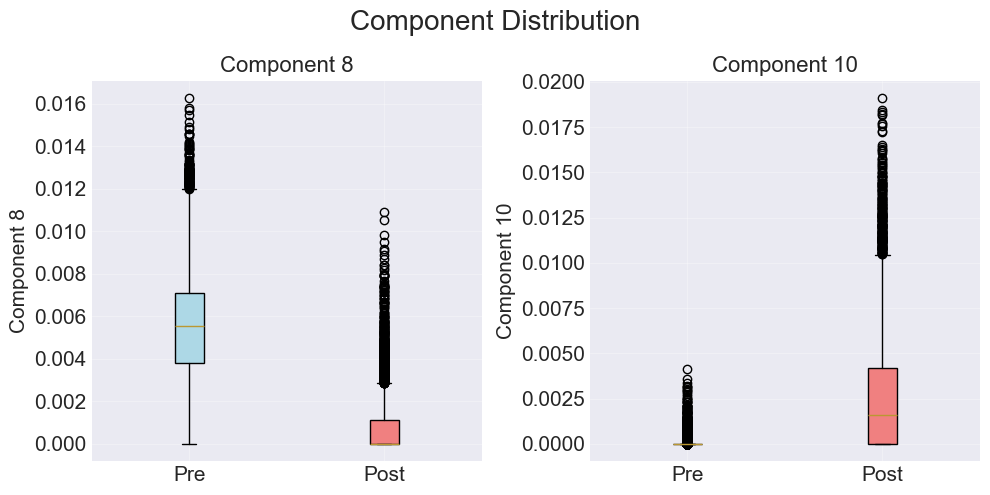


Fold Change:
Component 8: 0.1661
Component 10: 42.5352


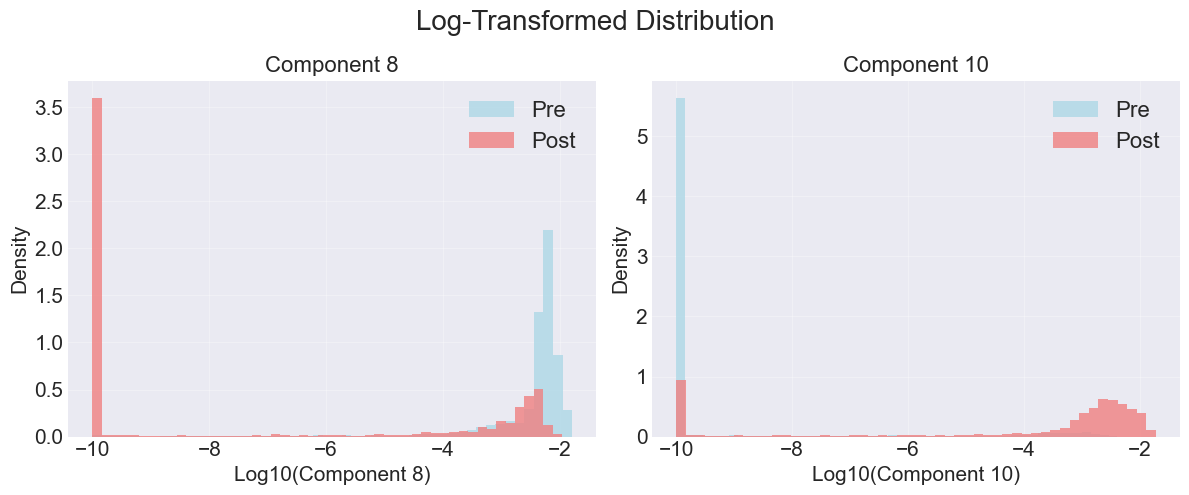

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Extract data
components_to_check = [7, 9]
component_names = [8, 10]

# Figure 1: Boxplots only
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Component Distribution', fontsize=20)

for idx, (comp_idx, comp_name) in enumerate(zip(components_to_check, component_names)):
    factor_values = H_transposed[:, comp_idx]
    pre_vals = factor_values[condition_binary == 0]
    post_vals = factor_values[condition_binary == 1]
    
    ax = axes[idx]
    box_data = [pre_vals, post_vals]
    bp = ax.boxplot(box_data, labels=['Pre', 'Post'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    ax.set_ylabel(f'Component {comp_name}', fontsize=15)
    ax.set_title(f'Component {comp_name}', fontsize=16)
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize=15)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate fold change
print("\nFold Change:")
for comp_idx, comp_name in zip(components_to_check, component_names):
    factor_values = H_transposed[:, comp_idx]
    pre_vals = factor_values[condition_binary == 0]
    post_vals = factor_values[condition_binary == 1]
    
    mean_pre = np.mean(pre_vals)
    mean_post = np.mean(post_vals)
    fold_change = mean_post / mean_pre
    
    print(f"Component {comp_name}: {fold_change:.4f}")

# Figure 2: Log-transformed distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Log-Transformed Distribution', fontsize=20)

for idx, (comp_idx, comp_name) in enumerate(zip(components_to_check, component_names)):
    factor_values = H_transposed[:, comp_idx]
    pre_vals = np.log10(factor_values[condition_binary == 0] + 1e-10)
    post_vals = np.log10(factor_values[condition_binary == 1] + 1e-10)
    
    ax = axes[idx]
    ax.hist(pre_vals, bins=50, alpha=0.8, label='Pre', density=True, color='lightblue')
    ax.hist(post_vals, bins=50, alpha=0.8, label='Post', density=True, color='lightcoral')
    
    ax.set_xlabel(f'Log10(Component {comp_name})', fontsize=15)
    ax.set_ylabel('Density', fontsize=15)
    ax.set_title(f'Component {comp_name}', fontsize=16)
    ax.tick_params(axis='both', labelsize=15)
    ax.legend(fontsize=16)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

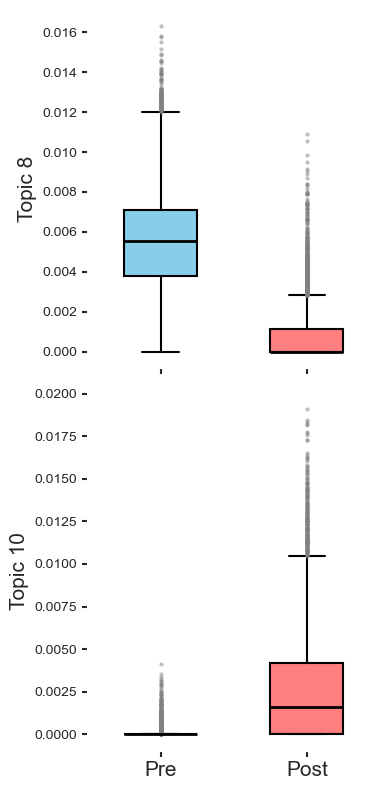

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Extract data
components_to_check = [7, 9]
component_names = [8, 10]

# Figure with white background
fig, axes = plt.subplots(2, 1, figsize=(4, 8))
fig.patch.set_facecolor('white')

for idx, (comp_idx, comp_name) in enumerate(zip(components_to_check, component_names)):
    factor_values = H_transposed[:, comp_idx]
    pre_vals = factor_values[condition_binary == 0]
    post_vals = factor_values[condition_binary == 1]
    
    ax = axes[idx]
    ax.set_facecolor('white')
    
    positions = [1, 2]
    box_data = [pre_vals, post_vals]
    
    bp = ax.boxplot(box_data, positions=positions, widths=0.5, patch_artist=True,
                    boxprops=dict(linewidth=1.5),
                    whiskerprops=dict(linewidth=1.5, color='black'),
                    capprops=dict(linewidth=1.5, color='black'),
                    medianprops=dict(linewidth=2, color='black'),
                    flierprops=dict(marker='o', markersize=3, markerfacecolor='gray', 
                                   markeredgecolor='none', alpha=0.5))
    
    bp['boxes'][0].set_facecolor('#87CEEB')
    bp['boxes'][0].set_edgecolor('black')
    bp['boxes'][1].set_facecolor('#FF7F7F')
    bp['boxes'][1].set_edgecolor('black')
    
    ax.set_ylabel(f'Topic {comp_name}', fontsize=15, fontweight='normal')
    ax.set_xlim(0.5, 2.5)
    ax.set_xticks(positions)
    
    if idx == 1:
        ax.set_xticklabels(['Pre', 'Post'], fontsize=15)
    else:
        ax.set_xticklabels([])
    
    ax.tick_params(axis='y', labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(width=1.5, length=4)

plt.tight_layout()
plt.show()

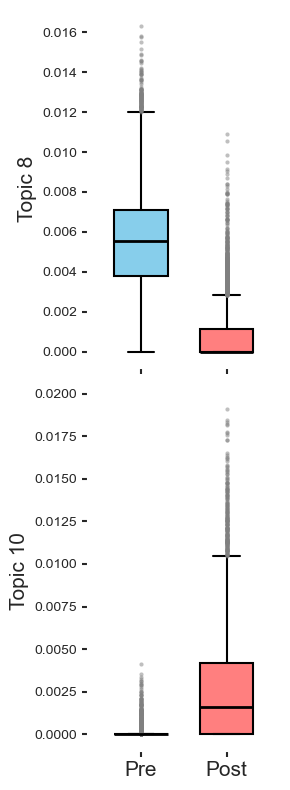

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Extract data
components_to_check = [7, 9]
component_names = [8, 10]

# Figure with white background
fig, axes = plt.subplots(2, 1, figsize=(3, 8))
fig.patch.set_facecolor('white')

for idx, (comp_idx, comp_name) in enumerate(zip(components_to_check, component_names)):
    factor_values = H_transposed[:, comp_idx]
    pre_vals = factor_values[condition_binary == 0]
    post_vals = factor_values[condition_binary == 1]
    
    ax = axes[idx]
    ax.set_facecolor('white')
    
    positions = [1, 1.8]
    box_data = [pre_vals, post_vals]
    
    bp = ax.boxplot(box_data, positions=positions, widths=0.5, patch_artist=True,
                    boxprops=dict(linewidth=1.5),
                    whiskerprops=dict(linewidth=1.5, color='black'),
                    capprops=dict(linewidth=1.5, color='black'),
                    medianprops=dict(linewidth=2, color='black'),
                    flierprops=dict(marker='o', markersize=3, markerfacecolor='gray', 
                                   markeredgecolor='none', alpha=0.5))
    
    bp['boxes'][0].set_facecolor('#87CEEB')
    bp['boxes'][0].set_edgecolor('black')
    bp['boxes'][1].set_facecolor('#FF7F7F')
    bp['boxes'][1].set_edgecolor('black')
    
    ax.set_ylabel(f'Topic {comp_name}', fontsize=15, fontweight='normal')
    ax.set_xlim(0.5, 2.3)
    ax.set_xticks(positions)
    
    if idx == 1:
        ax.set_xticklabels(['Pre', 'Post'], fontsize=15)
    else:
        ax.set_xticklabels([])
    
    ax.tick_params(axis='y', labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(width=1.5, length=4)

plt.tight_layout()
plt.show()

In [42]:
from scipy.stats import mannwhitneyu, ranksums
   
   # Use non-parametric tests as primary
u_stat, p_mann = mannwhitneyu(pre_vals, post_vals, alternative='two-sided')
z_stat, p_wilcox = ranksums(pre_vals, post_vals)

In [44]:
p_wilcox

np.float64(0.0)

In [37]:
import numpy as np
from scipy.stats import ttest_ind

# Prepare data
H_transposed = H_norm_T # Shape: (n_samples, n_components)
n_components = H_transposed.shape[1]
conditions = adata_X.obs['condition'].values

# Binary encoding: 0 for pre, 1 for post
condition_binary = np.array([0 if 'pre' in c.lower() else 1 for c in conditions])

print(f"Testing {n_components} components")
print(f"Pre-transplant: {sum(condition_binary==0)} samples")
print(f"Post-transplant: {sum(condition_binary==1)} samples")
print("\n" + "="*60)
print("Component | P-value      | Direction (Higher in)")
print("-"*60)

# Test all components
results = []
for i in range(4):
    factor_values = H_transposed[:, i]
    pre_vals = factor_values[condition_binary == 0]
    post_vals = factor_values[condition_binary == 1]
    
    # T-test
    t_stat, p_value = ttest_ind(pre_vals, post_vals, equal_var=False)
    
    # Prevent exact 0 p-value
    p_value = max(p_value, 1e-308)  # Smallest float value
    
    # Determine direction
    mean_pre = np.mean(pre_vals)
    mean_post = np.mean(post_vals)
    direction = "Post" if mean_post > mean_pre else "Pre"
    
    results.append({
        'component': i,
        'p_value': p_value,
        'direction': direction,
        'mean_diff': mean_post - mean_pre
    })
    
    print(f"Component {i+1:2} | {p_value:.4e} | {direction}-transplant")

# Sort by p-value and get top 4
results_sorted = sorted(results, key=lambda x: x['p_value'])
top4 = results_sorted[:4]

print("\n" + "="*60)
print("TOP 4 MOST SIGNIFICANT COMPONENTS:")
print("-"*60)
for r in top4:
    print(f"Component {r['component']+1}: p={r['p_value']:.4e}, Higher in {r['direction']}")

# Store indices for later use
top4_idx = [r['component'] for r in top4]

Testing 10 components
Pre-transplant: 3933 samples
Post-transplant: 3965 samples

Component | P-value      | Direction (Higher in)
------------------------------------------------------------
Component  1 | 1.0000e-308 | Post-transplant
Component  2 | 5.9645e-276 | Pre-transplant
Component  3 | 1.6195e-28 | Post-transplant
Component  4 | 3.8832e-61 | Post-transplant

TOP 4 MOST SIGNIFICANT COMPONENTS:
------------------------------------------------------------
Component 1: p=1.0000e-308, Higher in Post
Component 2: p=5.9645e-276, Higher in Pre
Component 4: p=3.8832e-61, Higher in Post
Component 3: p=1.6195e-28, Higher in Post


In [36]:
# Correct normalization for NMF H matrix
H_normalized = H_X_nmf_sse / H_X_nmf_sse.sum(axis=0, keepdims=True)
H_norm_T = H_normalized.T

# Re-test with normalized data
condition_binary = np.array([0 if 'pre' in c.lower() else 1 for c in adata_X.obs['condition'].values])

results = []
for i in range(H_norm_T.shape[1]):
    pre_vals = H_norm_T[condition_binary == 0, i]
    post_vals = H_norm_T[condition_binary == 1, i]
    
    t_stat, p_value = ttest_ind(pre_vals, post_vals, equal_var=False)
    p_value = max(p_value, 1e-308)
    
    mean_diff = np.mean(post_vals) - np.mean(pre_vals)
    direction = "Post" if mean_diff > 0 else "Pre"
    
    results.append({
        'component': i,
        'p_value': p_value,
        'direction': direction,
        'mean_diff': mean_diff
    })

# Sort and get top 4
results_sorted = sorted(results, key=lambda x: x['p_value'])
top4_idx = [r['component'] for r in results_sorted[:4]]

In [595]:
results_sorted

[{'component': 0,
  'p_value': 1e-308,
  'direction': 'Pre',
  'mean_diff': np.float32(-0.10220203)},
 {'component': 1,
  'p_value': 1e-308,
  'direction': 'Post',
  'mean_diff': np.float32(0.093793035)},
 {'component': 2,
  'p_value': 1e-308,
  'direction': 'Post',
  'mean_diff': np.float32(0.24490613)},
 {'component': 3,
  'p_value': 1e-308,
  'direction': 'Pre',
  'mean_diff': np.float32(-0.09039578)},
 {'component': 4,
  'p_value': 1e-308,
  'direction': 'Post',
  'mean_diff': np.float32(0.20691839)},
 {'component': 5,
  'p_value': 1e-308,
  'direction': 'Pre',
  'mean_diff': np.float32(-0.09869278)},
 {'component': 7,
  'p_value': 1e-308,
  'direction': 'Pre',
  'mean_diff': np.float32(-0.116825245)},
 {'component': 8,
  'p_value': 1e-308,
  'direction': 'Pre',
  'mean_diff': np.float32(-0.077222876)},
 {'component': 9,
  'p_value': np.float64(1.0541271645338457e-183),
  'direction': 'Pre',
  'mean_diff': np.float32(-0.04206324)},
 {'component': 6,
  'p_value': np.float64(2.419667

In [574]:
H_normalized.shape

(10, 7898)

In [599]:
post_vals

array([0.18531203, 0.09457786, 0.00225865, ..., 0.02210875, 0.00054141,
       0.15881741], dtype=float32)

In [600]:
post_vals.shape

(3965,)

In [598]:
ttest_ind(pre_vals, post_vals, equal_var=False)

TtestResult(statistic=np.float64(52.45541909231516), pvalue=np.float64(0.0), df=np.float64(5888.376956731101))

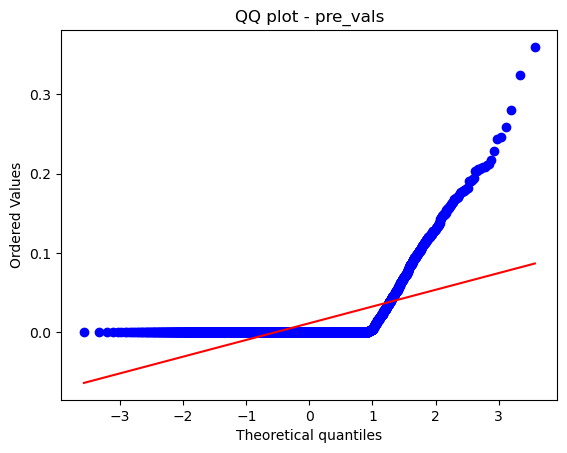

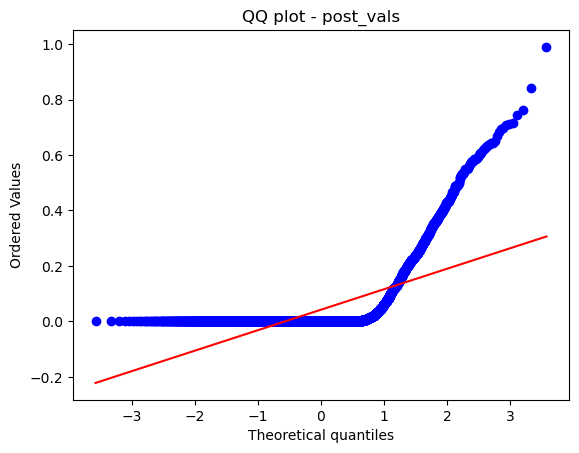

In [38]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(pre_vals, dist="norm", plot=plt)
plt.title("QQ plot - pre_vals")
plt.show()

stats.probplot(post_vals, dist="norm", plot=plt)
plt.title("QQ plot - post_vals")
plt.show()

In [602]:
import numpy as np

mean_pre = np.mean(pre_vals)
mean_post = np.mean(post_vals)
std_pre = np.std(pre_vals, ddof=1)
std_post = np.std(post_vals, ddof=1)

print("Mean pre:", mean_pre)
print("Mean post:", mean_post)
print("Std pre:", std_pre)
print("Std post:", std_post)

Mean pre: 0.13021529
Mean post: 0.039819505
Std pre: 0.09605336
Std post: 0.049735572


In [603]:
n1, n2 = len(pre_vals), len(post_vals)
pooled_std = np.sqrt(((n1 - 1)*std_pre**2 + (n2 - 1)*std_post**2) / (n1 + n2 - 2))
cohen_d = (mean_pre - mean_post) / pooled_std
print("Cohen's d:", cohen_d)

Cohen's d: 1.1832623


In [591]:
from scipy.stats import mannwhitneyu

# Assuming you already have pre_vals and post_vals as NumPy arrays
u_stat, p_val = mannwhitneyu(pre_vals, post_vals, alternative='two-sided')

print(f"Mann–Whitney U statistic: {u_stat}")
print(f"p-value: {p_val:.3e}")

Mann–Whitney U statistic: 11096986.5
p-value: 1.111e-232


In [592]:
n1, n2 = len(pre_vals), len(post_vals)
r_rb = 1 - (2 * u_stat) / (n1 * n2)
print(f"Rank-biserial correlation (effect size): {r_rb:.3f}")

Rank-biserial correlation (effect size): -0.423


In [39]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import seaborn as sns
from scipy.stats import ttest_ind
import matplotlib.colors as mcolors
colors_diverging = ['#FFB68A', 'white', '#8FB4D9']
n_bins = 256
cmap_custom = mcolors.LinearSegmentedColormap.from_list('custom_diverging', colors_diverging, N=n_bins)

colors_loading = ['white', '#b9afe1', '#e7a9d0']  # White to olive green to dark green
cmap_loading = mcolors.LinearSegmentedColormap.from_list('custom_loading', colors_loading, N=256)

# Get component p-values and directions from earlier testing
comp_pvals = []
comp_directions = []

for comp_idx in top4_idx:
    factor_values = H_transposed[:, comp_idx]
    pre_vals = factor_values[condition_binary == 0]
    post_vals = factor_values[condition_binary == 1]
    
    t_stat, p_value = ttest_ind(pre_vals, post_vals, equal_var=False)
    p_value = max(p_value, 1e-308)
    
    direction = 'Post' if np.mean(post_vals) > np.mean(pre_vals) else 'Pre'
    comp_pvals.append(p_value)
    comp_directions.append(direction)

# Get gene p-values with direction from regression results
gene_signed = [-np.log10(r['p_value']) if r['direction'] == 'Up in Pre' else np.log10(r['p_value']) 
               for r in regression_results]

# Define new order: C8, C6, C10, C1
new_component_order = [7, 5, 9, 0]  # Components 8, 6, 10, 1

# Find which position each desired component is in top4_idx
reorder_indices = []
for desired_comp in new_component_order:
    for i, comp in enumerate(top4_idx):
        if comp == desired_comp:
            reorder_indices.append(i)
            break

# Reorder components
top4_idx_reordered = [top4_idx[i] for i in reorder_indices]
comp_pvals_reordered = [comp_pvals[i] for i in reorder_indices]
comp_directions_reordered = [comp_directions[i] for i in reorder_indices]

# Create modified loading matrix - multiply ONLY columns 2 and 3 (C10 and C1) by 10
loading_matrix_modified = loading_matrix.copy()
loading_matrix_reordered = loading_matrix_modified[:, reorder_indices]
# Multiply columns 2 and 3 (C10 and C1 positions after reordering)
loading_matrix_reordered[:, 2] *= 5  # C10
loading_matrix_reordered[:, 3] *= 5  # C1

# Reorder genes (rows) to match new component order
new_gene_order = []
for comp_idx in top4_idx_reordered:
    for i, gene_info in enumerate(selected_genes):
        if gene_info['component'] == comp_idx:
            new_gene_order.append(i)

# Reorder everything
loading_matrix_final = loading_matrix_reordered[new_gene_order, :]
selected_genes_reordered = [selected_genes[i] for i in new_gene_order]
gene_signed_reordered = [gene_signed[i] for i in new_gene_order]

# Component signed values
comp_signed_reordered = [-np.log10(p) if d == 'Pre' else np.log10(p) 
                         for p, d in zip(comp_pvals_reordered, comp_directions_reordered)]

# Create figure
fig = plt.figure(figsize=(3, 9))
gs = gridspec.GridSpec(2, 4, height_ratios=[20, 1.2], width_ratios=[4, 0.8, 0.2, 0.5], 
                       hspace=0.02, wspace=0.01)

# Main heatmap - NO TEXT VALUES
ax_main = fig.add_subplot(gs[0, 0])
# Adjust vmax for scaled values
im1 = ax_main.imshow(loading_matrix_final, cmap=cmap_loading, aspect='auto', vmin=0, vmax=0.8)

# Gene significance heatmap
ax_genes = fig.add_subplot(gs[0, 1])
gene_signed_array = np.array(gene_signed_reordered).reshape(-1, 1)
gene_signed_clipped = np.clip(gene_signed_array, -300, 300)
im2 = ax_genes.imshow(gene_signed_clipped, cmap=cmap_custom, aspect='auto', 
                      vmin=-300, vmax=300)

# Component significance (bottom)
ax_comp = fig.add_subplot(gs[1, 0])
comp_signed_array = np.array(comp_signed_reordered).reshape(1, -1)
comp_signed_clipped = np.clip(comp_signed_array, -300, 300)
im3 = ax_comp.imshow(comp_signed_clipped, cmap=cmap_custom, aspect='auto', 
                     vmin=-300, vmax=300)

# Labels for main heatmap
ax_main.set_xticks(range(4))
ax_main.set_xticklabels(['', '', '', ''])  # Empty labels
ax_main.set_yticks(range(20))

# Gene labels - NO asterisks, keep original names
ylabels = []
for i, g in enumerate(selected_genes_reordered):
    if i % 5 == 0:
        ylabels.append(f"{g['gene_name']} (C{g['component']+1})")
    else:
        ylabels.append(g['gene_name'])
        
ax_main.set_yticklabels(ylabels, fontsize=9)

# Gene significance labels
ax_genes.set_xticks([0])
ax_genes.set_xticklabels(['Protein\nSig.'], fontsize=8)
ax_genes.set_yticks([])

# Component p-values - show numbers in the bar
ax_comp.set_xticks([])
ax_comp.set_yticks([0])
ax_comp.set_yticklabels(['P-value'], fontsize=9)

# Add component labels and p-values properly positioned
for i, (idx, pval) in enumerate(zip(top4_idx_reordered, comp_pvals_reordered)):
    # Component name below
    ax_comp.text(i, 0.6, f'F{idx+1}', ha='center', va='top', fontsize=10)
    # P-value in the bar
    ax_comp.text(i, 0, f'{-np.log10(pval):.0f}', ha='center', va='center', 
                fontsize=8, color='white' if abs(comp_signed_reordered[i]) > 150 else 'black')

# Titles
ax_main.set_title('NMF\nLoadings', fontsize=11, pad=10)

# Remove spines
for ax in [ax_main, ax_genes, ax_comp]:
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(left=False, bottom=False, top=False, right=False)

# Add grid lines between component groups
for y in [4.5, 9.5, 14.5]:
    ax_main.axhline(y=y, color='gray', linewidth=0.5, linestyle='-', alpha=0.3)

# Colorbars
cax1 = fig.add_axes([0.92, 0.55, 0.015, 0.12])
cb1 = plt.colorbar(im1, cax=cax1)
cb1.ax.set_ylabel('Loading', fontsize=9)
cb1.ax.tick_params(labelsize=9)

cax2 = fig.add_axes([0.92, 0.35, 0.015, 0.12])
cb2 = plt.colorbar(im2, cax=cax2)
cb2.ax.set_ylabel('Gene Sig.\n-log10(p)', fontsize=9)
cb2.ax.tick_params(labelsize=9)
cb2.set_ticks([-300, 0, 300])
cb2.set_ticklabels(['Post', '0', 'Pre'], fontsize=9)

cax3 = fig.add_axes([0.92, 0.15, 0.015, 0.08])
cb3 = plt.colorbar(im3, cax=cax3)
cb3.ax.set_ylabel('Component\n-log10(p)', fontsize=9)
cb3.ax.tick_params(labelsize=9)
cb3.set_ticks([-300, 0, 300])
cb3.set_ticklabels(['Post', '0', 'Pre'], fontsize=9)

#plt.suptitle('NMF Analysis: AML Pre vs Post Transplant', fontsize=13, y=0.96)
plt.tight_layout(rect=[0, 0, 0.9, 0.94])
plt.show()

NameError: name 'regression_results' is not defined

🔍 Finding top factors for each condition...
Top 2 Post-transplant factors: ['Factor_10', 'Factor_5']
Top 2 Pre-transplant factors: ['Factor_8', 'Factor_9']
All 4 selected factors: ['Factor_10', 'Factor_5', 'Factor_8', 'Factor_9']

🧬 Finding top 5 genes for each selected factor...

Factor_10 (bias: 0.954):
  1. MXD1: 146.3535
  2. CLEC2B: 132.4206
  3. HOXA9: 120.3342
  4. HBG2: 117.8225
  5. SAT1: 109.5496

Factor_5 (bias: 0.906):
  1. GNG11: 429.6447
  2. CLEC1B: 205.9348
  3. GP9: 190.2015
  4. ANXA3: 165.6970
  5. RGS18: 137.4676

Factor_8 (bias: -0.713):
  1. HBG2: 631.5279
  2. HBG1: 370.4231
  3. HBA2: 225.1094
  4. HBA1: 224.9150
  5. HBB: 142.1977

Factor_9 (bias: -0.665):
  1. HBG2: 274.6083
  2. HBG1: 170.8758
  3. HBA2: 76.8184
  4. HBA1: 75.6602
  5. HBB: 65.4021

📊 Heatmap data shape: (20, 4)


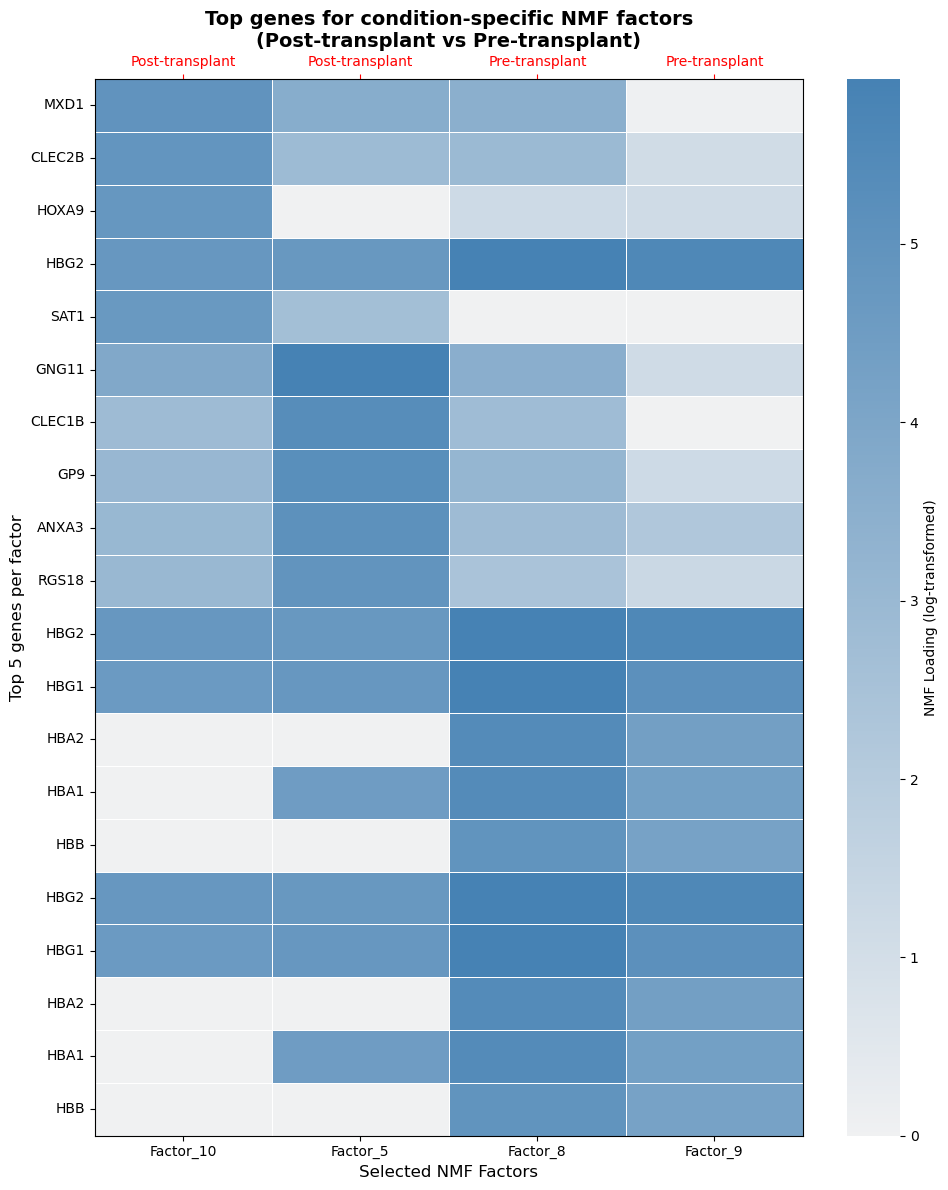


📊 Creating heatmap with column-wise normalization...


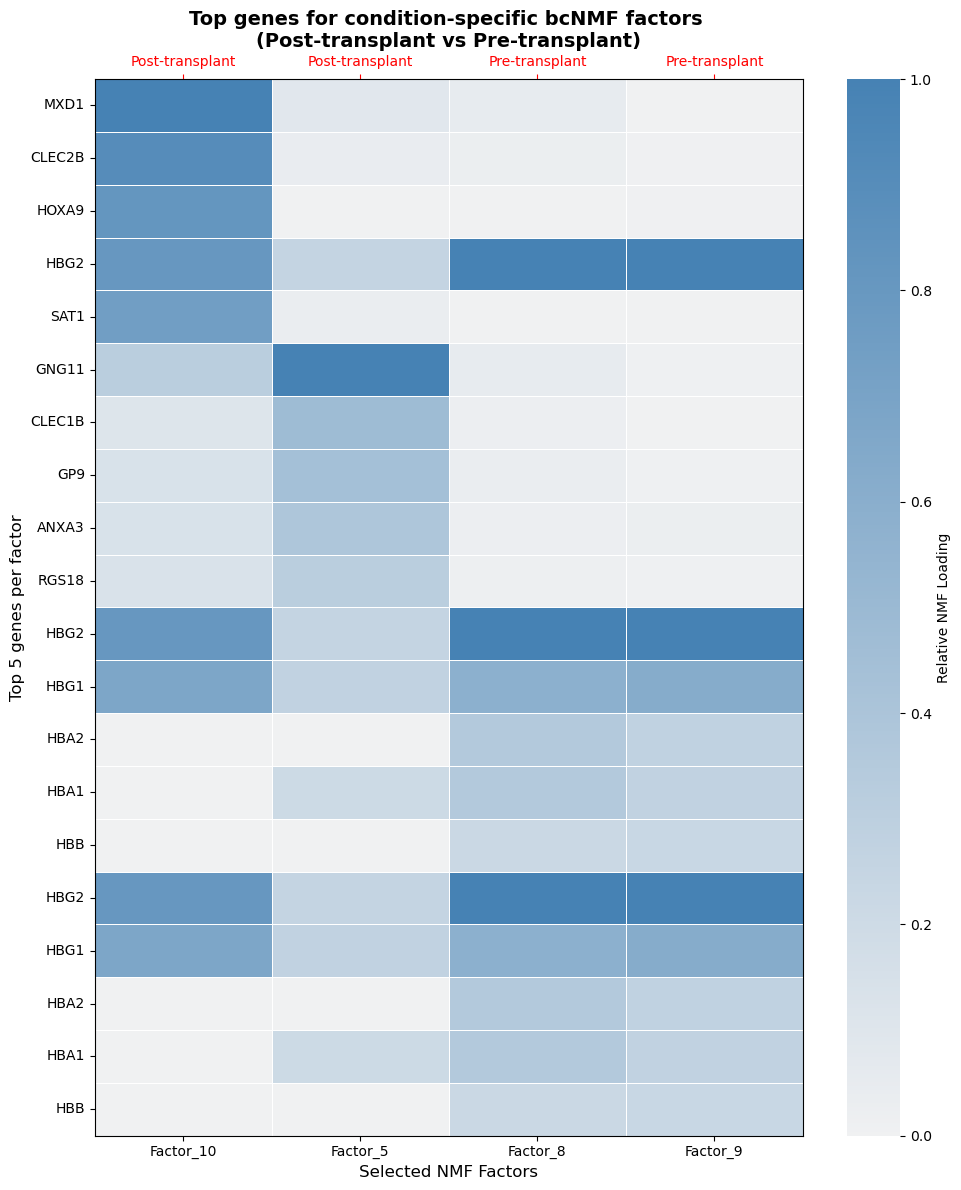


📊 Creating alternative heatmap with row-wise normalization...


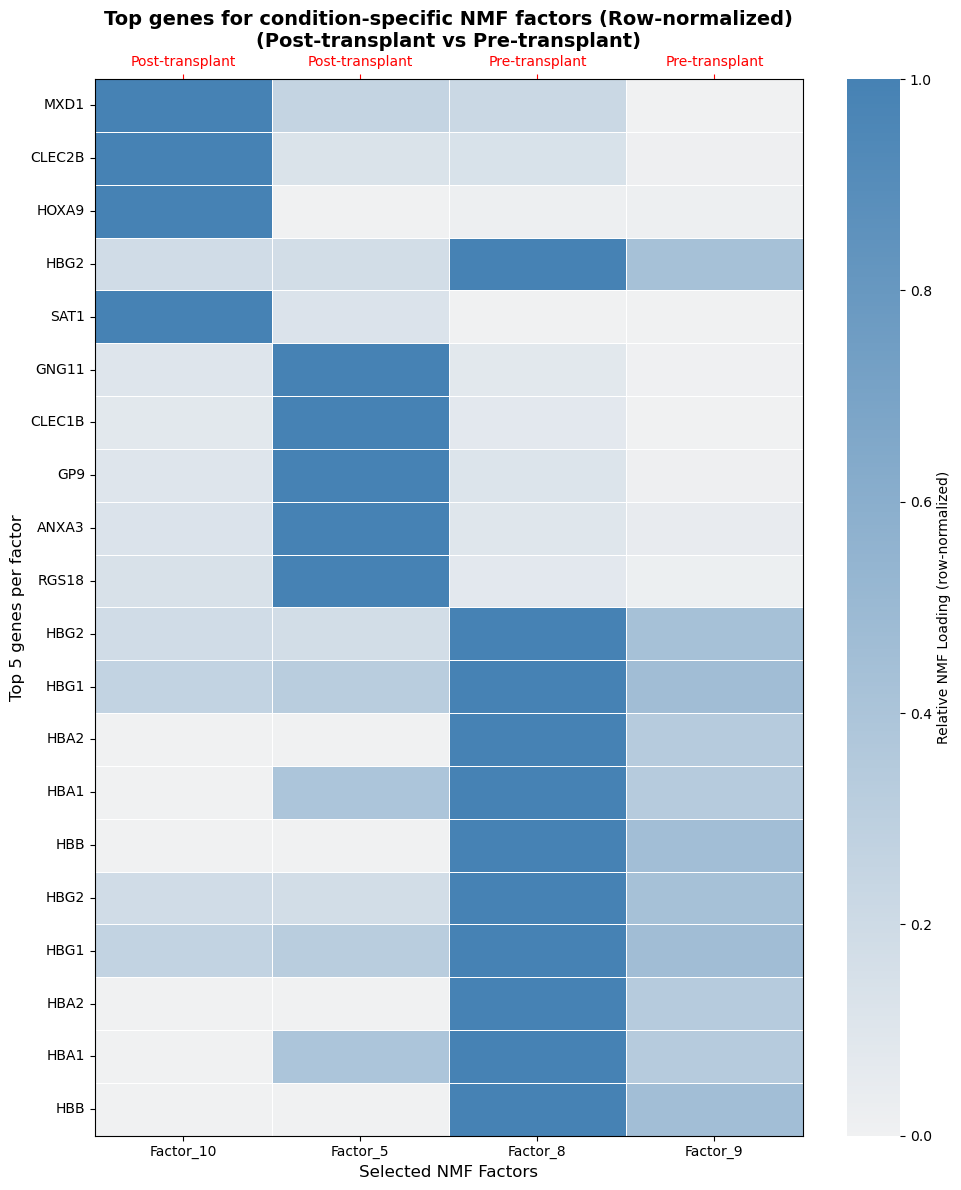


SUMMARY
Selected 4 factors based on condition bias:
1. Factor_10: Post-transplant biased (bias: 0.954)
2. Factor_5: Post-transplant biased (bias: 0.906)
3. Factor_8: Pre-transplant biased (bias: -0.713)
4. Factor_9: Pre-transplant biased (bias: -0.665)

Heatmap shows top 5 genes per factor based on NMF loadings
Each gene shows its loading values across all 4 selected factors

Genes appearing in multiple factors:
  HBG2: appears in 3 factors
  HBG1: appears in 2 factors
  HBA2: appears in 2 factors
  HBA1: appears in 2 factors
  HBB: appears in 2 factors


In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ── Step 1: Find top 2 factors for each condition based on relative loadings ────
print("🔍 Finding top factors for each condition...")

# Calculate bias scores to identify condition-specific factors
post_fraction = relative_loadings.loc['Post-transplant']
pre_fraction = relative_loadings.loc['Pre-transplant']
bias_scores = post_fraction - pre_fraction

# Get top 2 factors for each condition
top2_post_idx = np.argsort(bias_scores.values)[-2:][::-1]  # Top 2 post-transplant biased
top2_pre_idx = np.argsort(bias_scores.values)[:2]          # Top 2 pre-transplant biased

# Convert to factor names
top2_post_factors = [f'Factor_{i+1}' for i in top2_post_idx]
top2_pre_factors = [f'Factor_{i+1}' for i in top2_pre_idx]

# Combine all 4 factors
top4_factors = top2_post_factors + top2_pre_factors
top4_idx = list(top2_post_idx) + list(top2_pre_idx)

print(f"Top 2 Post-transplant factors: {top2_post_factors}")
print(f"Top 2 Pre-transplant factors: {top2_pre_factors}")
print(f"All 4 selected factors: {top4_factors}")

# ── Step 2: Get top 5 genes for each of the 4 factors ────
print("\n🧬 Finding top 5 genes for each selected factor...")

# Load gene names
gene_names = hvg_genes['gene_name'].values

rows, matrix = [], []
topN = 5  # genes per factor

for fac_idx, fac_name in zip(top4_idx, top4_factors):
    # Get top 5 genes with highest loadings for this factor
    top5_genes_idx = np.argsort(W_nmf_sse[:, fac_idx])[-topN:][::-1]  # highest loadings
    
    print(f"\n{fac_name} (bias: {bias_scores.iloc[fac_idx]:.3f}):")
    for i, gene_idx in enumerate(top5_genes_idx):
        gene_name = gene_names[gene_idx]
        loading_value = W_nmf_sse[gene_idx, fac_idx]
        print(f"  {i+1}. {gene_name}: {loading_value:.4f}")
        
        # Add to heatmap data
        rows.append(gene_name)
        # Get loading values for this gene across all 4 selected factors
        vals = W_nmf_sse[gene_idx, top4_idx]
        matrix.append(vals)

# ── Step 3: Create heatmap DataFrame ────
heat_df = pd.DataFrame(matrix, index=rows, columns=top4_factors)

print(f"\n📊 Heatmap data shape: {heat_df.shape}")

# ── Step 4: Create the heatmap with better scaling ────
plt.figure(figsize=(10, 12))

# Use log scaling or different vmax to make pre-transplant factors more visible
# Option 1: Use a lower percentile for vmax to enhance contrast
vmax = np.quantile(heat_df.values, 0.85)  # Lower percentile to enhance contrast

# Option 2: Apply log transformation for better visualization of small values
heat_df_log = np.log1p(heat_df)  # log(1 + x) to handle zeros

# Create heatmap with log-transformed data
sns.heatmap(heat_df_log,
            cmap=sns.light_palette("steelblue", as_cmap=True),
            vmin=0, 
            vmax=np.quantile(heat_df_log.values, 0.95),
            annot=False, 
            linewidths=0.4,
            cbar_kws={'label': 'NMF Loading (log-transformed)'},
            fmt='.3f')

# Customize the plot
plt.ylabel('Top 5 genes per factor', fontsize=12)
plt.xlabel('Selected NMF Factors', fontsize=12)
plt.title('Top genes for condition-specific NMF factors\n(Post-transplant vs Pre-transplant)', 
          fontsize=14, fontweight='bold')

# Add condition labels above factors
ax = plt.gca()
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([0.5, 1.5, 2.5, 3.5])
ax2.set_xticklabels(['Post-transplant', 'Post-transplant', 'Pre-transplant', 'Pre-transplant'])
ax2.tick_params(axis='x', colors='red', labelsize=10)

plt.tight_layout()
plt.show()

# ── Step 4: Create heatmap with column-wise normalization ────
print("\n📊 Creating heatmap with column-wise normalization...")

plt.figure(figsize=(10, 12))

# Normalize each factor (column) to its maximum value
# This makes the max gene in each factor have value 1
heat_df_col_normalized = heat_df.div(heat_df.max(axis=0), axis=1)

# Create heatmap with column-normalized data
sns.heatmap(heat_df_col_normalized,
            cmap=sns.light_palette("steelblue", as_cmap=True),
            vmin=0, 
            vmax=1,
            annot=False, 
            linewidths=0.4,
            cbar_kws={'label': 'Relative NMF Loading'},
            fmt='.3f')

# Customize the plot
plt.ylabel('Top 5 genes per factor', fontsize=12)
plt.xlabel('Selected NMF Factors', fontsize=12)
plt.title('Top genes for condition-specific bcNMF factors \n(Post-transplant vs Pre-transplant)', 
          fontsize=14, fontweight='bold')

# Add condition labels above factors
ax = plt.gca()
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([0.5, 1.5, 2.5, 3.5])
ax2.set_xticklabels(['Post-transplant', 'Post-transplant', 'Pre-transplant', 'Pre-transplant'])
ax2.tick_params(axis='x', colors='red', labelsize=10)

plt.tight_layout()
plt.show()

# ── Alternative: Create a second heatmap with row-wise normalization ────
print("\n📊 Creating alternative heatmap with row-wise normalization...")

plt.figure(figsize=(10, 12))

# Normalize each gene (row) to make relative patterns more visible
heat_df_normalized = heat_df.div(heat_df.max(axis=1), axis=0)

# Create heatmap with normalized data
sns.heatmap(heat_df_normalized,
            cmap=sns.light_palette("steelblue", as_cmap=True),
            vmin=0, 
            vmax=1,
            annot=False, 
            linewidths=0.4,
            cbar_kws={'label': 'Relative NMF Loading (row-normalized)'},
            fmt='.3f')

# Customize the plot
plt.ylabel('Top 5 genes per factor', fontsize=12)
plt.xlabel('Selected NMF Factors', fontsize=12)
plt.title('Top genes for condition-specific NMF factors (Row-normalized)\n(Post-transplant vs Pre-transplant)', 
          fontsize=14, fontweight='bold')

# Add condition labels above factors
ax = plt.gca()
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([0.5, 1.5, 2.5, 3.5])
ax2.set_xticklabels(['Post-transplant', 'Post-transplant', 'Pre-transplant', 'Pre-transplant'])
ax2.tick_params(axis='x', colors='red', labelsize=10)

plt.tight_layout()
plt.show()

# ── Step 5: Print summary information ────
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

print(f"Selected 4 factors based on condition bias:")
for i, (factor, bias) in enumerate(zip(top4_factors, [bias_scores.iloc[idx] for idx in top4_idx])):
    condition = "Post-transplant" if bias > 0 else "Pre-transplant"
    print(f"{i+1}. {factor}: {condition} biased (bias: {bias:.3f})")

print(f"\nHeatmap shows top {topN} genes per factor based on NMF loadings")
print("Each gene shows its loading values across all 4 selected factors")

# Optional: Show which genes appear in multiple factors
gene_counts = pd.Series(rows).value_counts()
shared_genes = gene_counts[gene_counts > 1]
if len(shared_genes) > 0:
    print(f"\nGenes appearing in multiple factors:")
    for gene, count in shared_genes.items():
        print(f"  {gene}: appears in {count} factors")
else:
    print(f"\nNo genes shared between factors (each gene is top-5 in only one factor)")

In [500]:
gene_names.shape

(2003,)